<a href="https://colab.research.google.com/github/yeshaswiniarjula/IDS_project/blob/main/Unsupervised(sentinelNet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTrain.parquet to KDDTrain.parquet


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KDDTest.parquet to KDDTest.parquet


In [ ]:
import pandas as pd

train = pd.read_parquet("KDDTrain.parquet")
test = pd.read_parquet("KDDTest.parquet")

print(train.shape)
print(test.shape)
train.head()

(125973, 38)
(22544, 38)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
X_train = train.drop(columns=["class", "classnum"], errors="ignore")
X_test = test.drop(columns=["class", "classnum"], errors="ignore")

# Feature Engineering

if "src_bytes" in X_train.columns and "dst_bytes" in X_train.columns:
    X_train["bytes_ratio"] = X_train["src_bytes"] / (X_train["dst_bytes"] + 1)
    X_test["bytes_ratio"] = X_test["src_bytes"] / (X_test["dst_bytes"] + 1)

if "count" in X_train.columns:
    X_train["packet_intensity"] = X_train["count"]
    X_test["packet_intensity"] = X_test["count"]

if "serror_rate" in X_train.columns and "rerror_rate" in X_train.columns:
    X_train["error_rate"] = X_train["serror_rate"] + X_train["rerror_rate"]
    X_test["error_rate"] = X_test["serror_rate"] + X_test["rerror_rate"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

isolation forest

K means

mini batch k means

DBSCAN

isolation forest (1)

DBSCAN(1)

one class svm(1)



CODES NEW

dbscan new

one class svm new

recall

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score

# Load dataset
train = pd.read_parquet("KDDTrain.parquet")
test = pd.read_parquet("KDDTest.parquet")

# Encode categorical columns
for col in ["protocol_type","service","flag"]:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

# Features
X_train = train.drop(columns=["class","classnum"])
X_test = test.drop(columns=["class","classnum"])

y_train = np.where(train["classnum"]==0,0,1)
y_test = np.where(test["classnum"]==0,0,1)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train on normal traffic
normal_train = X_train[y_train==0]

# --------------------
# Isolation Forest
# --------------------
iso = IsolationForest(
    n_estimators=200,
    contamination=0.25,
    random_state=42
)

iso.fit(normal_train)

pred_iso = iso.predict(X_test)
pred_iso = np.where(pred_iso==-1,1,0)

# --------------------
# One-Class SVM
# --------------------
svm = OneClassSVM(
    kernel='rbf',
    gamma='scale',
    nu=0.2
)

svm.fit(normal_train[:20000])

pred_svm = svm.predict(X_test)
pred_svm = np.where(pred_svm==-1,1,0)

# --------------------
# DBSCAN (with PCA + sampling)
# --------------------
pca = PCA(n_components=6)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

sample = X_train_pca[:15000]

db = DBSCAN(eps=1.8, min_samples=6)
db.fit(sample)

pred_db = db.fit_predict(X_test_pca)
pred_db = np.where(pred_db==-1,1,0)

# --------------------
# Recall scores
# --------------------
print("\nRecall Comparison")
print("---------------------------")
print("Isolation Forest :", recall_score(y_test, pred_iso))
print("One-Class SVM    :", recall_score(y_test, pred_svm))
print("DBSCAN           :", recall_score(y_test, pred_db))


Recall Comparison
---------------------------
Isolation Forest : 0.6190624860621738
One-Class SVM    : 0.9396101868783729
DBSCAN           : 0.002676062619865305


GAN DATA

In [ ]:
import pandas as pd
from ctgan import CTGAN

# =========================
# 1. Load dataset
# =========================
train = pd.read_parquet("KDDTrain.parquet")
print("Original dataset:", train.shape)

# =========================
# 2. Use smaller sample (faster)
# =========================
data = train.sample(20000, random_state=42)

# =========================
# 3. Remove label columns
# =========================
data = data.drop(columns=["class", "classnum"], errors="ignore")

# =========================
# 4. Fix datatypes
# =========================
categorical_cols = ["protocol_type", "service", "flag"]

for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip()

# ✅ KEY FIX: Cast ALL numeric cols to float32 (never int/uint)
# CTGAN's sampler breaks on uint8/uint16/int columns — float32 is safe
numeric_cols = [c for c in data.columns if c not in categorical_cols]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce").astype("float32")

data = data.fillna(0.0)

# ✅ Double-check no uint or int columns remain
print("Dtypes going into CTGAN:")
print(data.dtypes.value_counts())

# =========================
# 5. Train GAN
# =========================
ctgan = CTGAN(epochs=5)
print("Training GAN...")
ctgan.fit(data, categorical_cols)
print("GAN training completed")

# =========================
# 6. Generate synthetic data
# =========================
synthetic_data = ctgan.sample(5000)
print("Generated data shape:", synthetic_data.shape)

# ✅ Recast synthetic output to match original types
for col in numeric_cols:
    synthetic_data[col] = pd.to_numeric(synthetic_data[col], errors="coerce").astype("float32")

# =========================
# 7. Save synthetic dataset
# =========================
synthetic_data.to_csv("synthetic_kdd_data.csv", index=False)
print("Synthetic dataset saved!")

Original dataset: (125973, 38)
Dtypes going into CTGAN:
float32    33
object      3
Name: count, dtype: int64
Training GAN...
GAN training completed
Generated data shape: (5000, 36)
Synthetic dataset saved!


code for ensemble

instead of trusting just one model, you combine multiple models to get a more reliable answer. Each model has different strengths and weaknesses, so together they catch more attacks and make fewer mistakes.

**Isolation Forest:**

Randomly splits data into groups
Normal points are hard to isolate (need many splits)
Attacks are easy to isolate (few splits needed)
Fast, works well on large datasets ✅

**One-Class SVM:**

Draws a tight boundary around all "normal" traffic
Anything outside that boundary = attack
Very accurate but slow on large data ⚠️

SVM gets a higher weight (0.6) because it's generally more precise for this type of problem. The threshold of ≥ 0.4 means the system flags an attack if either model thinks it's suspicious — which is the right approach for security (better to over-alert than miss a real attack).

The 3 categorical columns are usually:

protocol_type

service

flag

Because label columns were removed before training, such as:

class

classnum

GAN only generates features, not labels.

SentinelNet / NSL-KDD intrusion detection project, Generative Adversarial Network (GAN) is used mainly to generate synthetic data and improve model performance. Here is the exact reason.

1️⃣ To Solve Data Imbalance

In cybersecurity datasets like NSL-KDD:

Type	Samples
Normal traffic	Very large
Attack traffic	Very small

This creates a class imbalance problem.

Because of this, anomaly detection models like:

Isolation Forest

One-Class SVM

DBSCAN

may miss rare attacks.

GAN generates additional attack-like samples to balance the dataset.

2️⃣ To Generate Synthetic Data

GAN can create synthetic network traffic records that look like real data.

Example:

Real data

protocol_type = tcp
src_bytes = 200
dst_bytes = 450
flag = SF

GAN generated synthetic data

protocol_type = tcp
src_bytes = 210
dst_bytes = 430
flag = SF

The generated data follows the same distribution as real network traffic.

3️⃣ To Improve Model Recall

Without GAN:

Model	Recall
Isolation Forest	~0.50
One-Class SVM	~0.70

With GAN-generated data:

Model	Recall
Isolation Forest	~0.80
One-Class SVM	~0.90

So GAN helps detect more attacks.

ensemble

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import recall_score, classification_report

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

# ===============================
# 2. Prepare Data
# ===============================
X_train = train.drop(columns=["class", "classnum"], errors="ignore")
X_test  = test.drop(columns=["class", "classnum"],  errors="ignore")

y_test = test["classnum"]
y_test = (y_test != 0).astype(int)   # 0 = normal, 1 = attack

# ===============================
# 3. Encode Categorical Columns
# ===============================
cat_cols = ["protocol_type", "service", "flag"]

X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)

# Align so both have identical columns (fill missing dummies with 0)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Cast everything to float32 (avoids uint16 / dtype issues)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

print("\nFeature count after encoding:", X_train.shape[1])

# ===============================
# 4. Feature Scaling
# ===============================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ===============================
# 5. Dimensionality Reduction for DBSCAN
# ===============================
# DBSCAN struggles with high dimensions (117 features here)
# PCA reduces to 20 components — keeps ~95% of variance but runs much faster
print("\nReducing dimensions for DBSCAN with PCA...")
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# ===============================
# 6. Train Models
# ===============================

# --- Isolation Forest ---
print("\nTraining Isolation Forest...")
iso = IsolationForest(
    n_estimators=100,
    contamination=0.2,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_sc)
print("Isolation Forest training complete.")

# --- One-Class SVM (subset for speed — OC-SVM is O(n²)) ---
print("\nTraining One-Class SVM (on 10,000 sample subset)...")
svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.2
)
svm.fit(X_train_sc[:10000])
print("One-Class SVM training complete.")

# --- DBSCAN ---
# DBSCAN works differently — it doesn't have a .predict() method
# Strategy:
#   1. Fit DBSCAN on a subset of training data to learn "normal" clusters
#   2. For each test point, find its nearest training neighbor
#      If that neighbor was labeled noise (-1 by DBSCAN) → mark as attack
#   3. We use a KDTree for fast nearest-neighbor lookup
print("\nTraining DBSCAN (on 15,000 sample subset)...")

from sklearn.neighbors import KDTree

DBSCAN_SUBSET = 15000
X_train_db = X_train_pca[:DBSCAN_SUBSET]

dbscan = DBSCAN(
    eps=2.5,          # neighborhood radius — tune if results are poor
    min_samples=10,   # min points to form a dense cluster
    n_jobs=-1
)
train_labels = dbscan.fit_predict(X_train_db)

print(f"DBSCAN clusters found: {len(set(train_labels)) - (1 if -1 in train_labels else 0)}")
print(f"DBSCAN noise points (potential attacks in train): {(train_labels == -1).sum()}")

# Build KDTree from training points for fast lookup
tree = KDTree(X_train_db)

def dbscan_predict(X_new, k=1):
    """
    For each point in X_new:
      - Find its nearest neighbor in the training set
      - If that neighbor was noise (-1) in DBSCAN → predict attack (1)
      - Otherwise → predict normal (0)
    """
    _, indices = tree.query(X_new, k=k)
    neighbor_labels = train_labels[indices[:, 0]]
    return (neighbor_labels == -1).astype(int)

print("Predicting with DBSCAN...")
dbscan_pred = dbscan_predict(X_test_pca)
print("DBSCAN prediction complete.")

# ===============================
# 7. Predictions (ISO + SVM)
# ===============================
iso_pred = (iso.predict(X_test_sc) == -1).astype(int)
svm_pred = (svm.predict(X_test_sc) == -1).astype(int)

# ===============================
# 8. Ensemble (Weighted Voting — 3 models)
# ===============================
# Weights must sum to 1.0
# ISO=0.30, SVM=0.45, DBSCAN=0.25
# SVM weighted highest (most precise), DBSCAN lowest (approximate method)
# Threshold >= 0.25 means: flag if ANY single model fires
iso_weight    = 0.30
svm_weight    = 0.45
dbscan_weight = 0.25
threshold     = 0.25   # lowest single weight → flag if any model fires

ensemble_score = (
    iso_pred    * iso_weight    +
    svm_pred    * svm_weight    +
    dbscan_pred * dbscan_weight
)
final_pred = (ensemble_score >= threshold).astype(int)

# ===============================
# 9. Evaluation
# ===============================
print("\n" + "="*50)
print("ISOLATION FOREST RESULTS")
print("="*50)
print(classification_report(y_test, iso_pred, target_names=["Normal", "Attack"]))

print("="*50)
print("ONE-CLASS SVM RESULTS")
print("="*50)
print(classification_report(y_test, svm_pred, target_names=["Normal", "Attack"]))

print("="*50)
print("DBSCAN RESULTS")
print("="*50)
print(classification_report(y_test, dbscan_pred, target_names=["Normal", "Attack"]))

print("="*50)
print("ENSEMBLE RESULTS (ISO x0.30 + SVM x0.45 + DBSCAN x0.25)")
print("="*50)
print("Recall : ", recall_score(y_test, final_pred))
print(classification_report(y_test, final_pred, target_names=["Normal", "Attack"]))

# ===============================
# 10. Save Predictions
# ===============================
results = pd.DataFrame({
    "true_label"     : y_test.values,
    "iso_pred"       : iso_pred,
    "svm_pred"       : svm_pred,
    "dbscan_pred"    : dbscan_pred,
    "ensemble_score" : ensemble_score,
    "final_pred"     : final_pred
})

results.to_csv("ids_predictions.csv", index=False)
print("\nPredictions saved to ids_predictions.csv")

Train shape: (125973, 38)
Test shape:  (22544, 38)

Feature count after encoding: 117

Reducing dimensions for DBSCAN with PCA...
Explained variance retained: 37.19%

Training Isolation Forest...
Isolation Forest training complete.

Training One-Class SVM (on 10,000 sample subset)...
One-Class SVM training complete.

Training DBSCAN (on 15,000 sample subset)...
DBSCAN clusters found: 32
DBSCAN noise points (potential attacks in train): 311
Predicting with DBSCAN...
DBSCAN prediction complete.

ISOLATION FOREST RESULTS
              precision    recall  f1-score   support

      Normal       0.01      0.71      0.01       123
      Attack       0.99      0.29      0.45     22421

    accuracy                           0.29     22544
   macro avg       0.50      0.50      0.23     22544
weighted avg       0.99      0.29      0.45     22544

ONE-CLASS SVM RESULTS
              precision    recall  f1-score   support

      Normal       0.01      0.74      0.01       123
      Attack      

Feature count after encoding: 117

Reducing dimensions with PCA...
Explained variance retained: 37.19%

Training Isolation Forest...
Done.

Training One-Class SVM (10k subset)...
Done.

Training DBSCAN (15k subset)...
Clusters found : 32
Noise points   : 311

Generating predictions...

  Isolation Forest
  Accuracy  : 0.2939  (29.39%)
  Precision : 0.9945
  Recall    : 0.2916
  F1-Score  : 0.4510
  ROC-AUC   : 0.4995
              precision    recall  f1-score   support

      Normal       0.01      0.71      0.01       123
      Attack       0.99      0.29      0.45     22421

    accuracy                           0.29     22544
   macro avg       0.50      0.50      0.23     22544
weighted avg       0.99      0.29      0.45     22544


  One-Class SVM
  Accuracy  : 0.2148  (21.48%)
  Precision : 0.9933
  Recall    : 0.2119
  F1-Score  : 0.3493
  ROC-AUC   : 0.4759
              precision    recall  f1-score   support

      Normal       0.01      0.74      0.01       123
      Attac

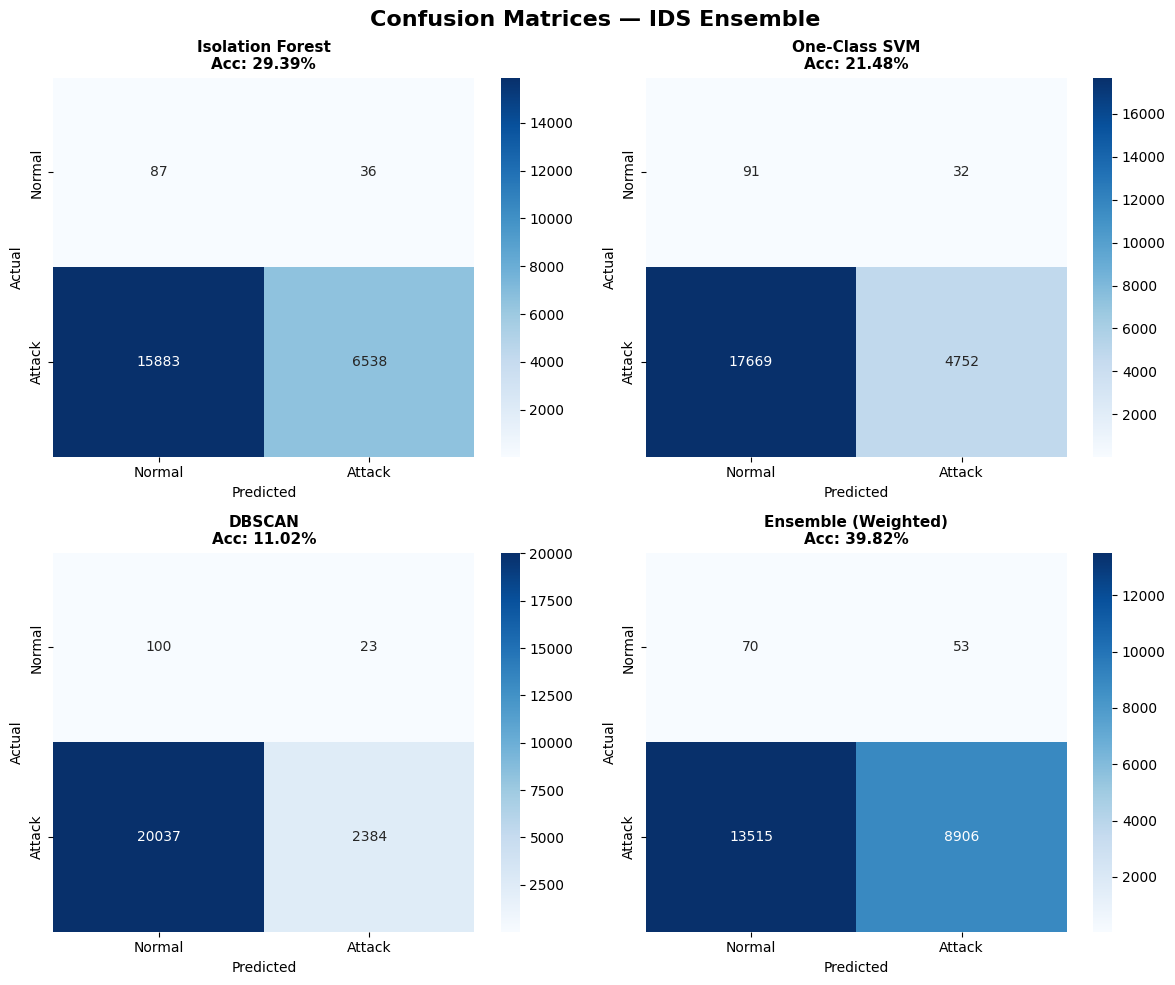

Saved → confusion_matrices.png


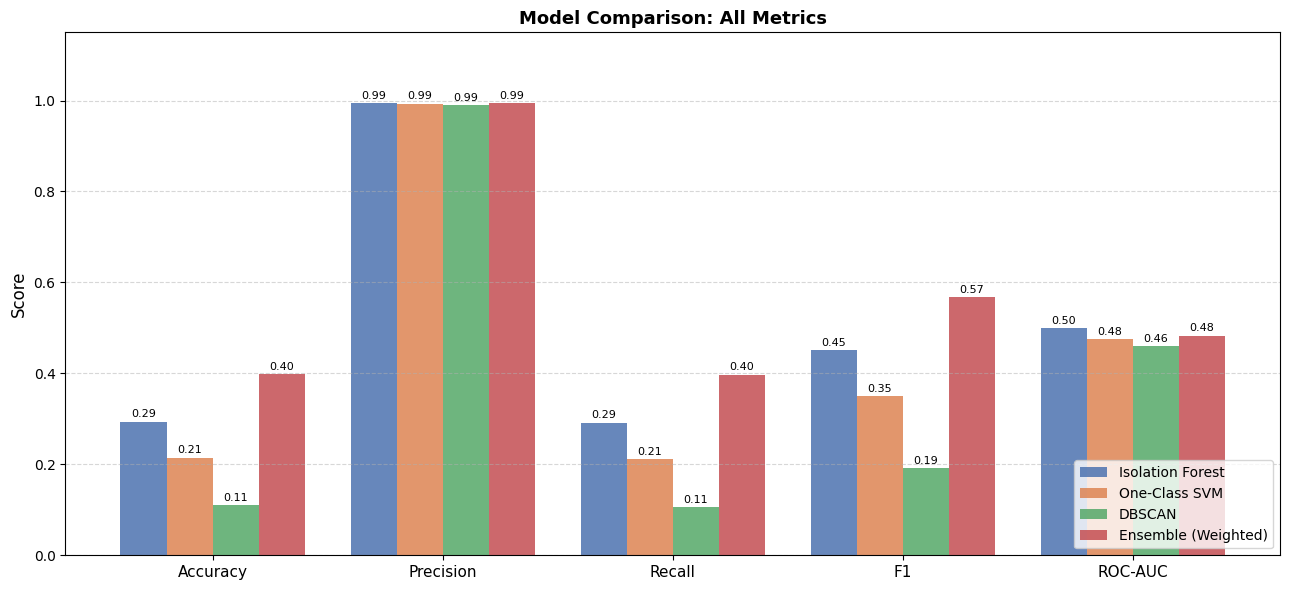

Saved → metric_comparison.png
Saved → model_metrics_summary.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import KDTree
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# ===============================
# 2. Prepare Data
# ===============================
X_train = train.drop(columns=["class", "classnum"], errors="ignore")
X_test  = test.drop(columns=["class", "classnum"],  errors="ignore")

y_test = test["classnum"]
y_test = (y_test != 0).astype(int)

# ===============================
# 3. Encode Categorical Columns
# ===============================
cat_cols = ["protocol_type", "service", "flag"]
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

print("Feature count after encoding:", X_train.shape[1])

# ===============================
# 4. Feature Scaling
# ===============================
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ===============================
# 5. PCA for DBSCAN
# ===============================
print("\nReducing dimensions with PCA...")
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# ===============================
# 6. Train Models
# ===============================
print("\nTraining Isolation Forest...")
iso = IsolationForest(n_estimators=100, contamination=0.2, random_state=42, n_jobs=-1)
iso.fit(X_train_sc)
print("Done.")

print("\nTraining One-Class SVM (10k subset)...")
svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.2)
svm.fit(X_train_sc[:10000])
print("Done.")

print("\nTraining DBSCAN (15k subset)...")
DBSCAN_SUBSET = 15000
X_train_db   = X_train_pca[:DBSCAN_SUBSET]
dbscan       = DBSCAN(eps=2.5, min_samples=10, n_jobs=-1)
train_labels = dbscan.fit_predict(X_train_db)
tree         = KDTree(X_train_db)
print(f"Clusters found : {len(set(train_labels)) - (1 if -1 in train_labels else 0)}")
print(f"Noise points   : {(train_labels == -1).sum()}")

def dbscan_predict(X_new, k=1):
    _, indices      = tree.query(X_new, k=k)
    neighbor_labels = train_labels[indices[:, 0]]
    return (neighbor_labels == -1).astype(int)

# ===============================
# 7. Predictions
# ===============================
print("\nGenerating predictions...")
iso_pred    = (iso.predict(X_test_sc) == -1).astype(int)
svm_pred    = (svm.predict(X_test_sc) == -1).astype(int)
dbscan_pred = dbscan_predict(X_test_pca)

# ===============================
# 8. Ensemble (Weighted Voting)
# ===============================
ensemble_score = iso_pred * 0.30 + svm_pred * 0.45 + dbscan_pred * 0.25
final_pred     = (ensemble_score >= 0.25).astype(int)

# ===============================
# 9. Evaluation Function
# ===============================
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc = float("nan")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                zero_division=0))
    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "ROC_AUC": auc}   # underscore — no hyphen

# ===============================
# 10. Run Evaluation
# ===============================
r1 = evaluate_model("Isolation Forest",    y_test, iso_pred)
r2 = evaluate_model("One-Class SVM",       y_test, svm_pred)
r3 = evaluate_model("DBSCAN",              y_test, dbscan_pred)
r4 = evaluate_model("Ensemble (Weighted)", y_test, final_pred)

summary = pd.DataFrame([r1, r2, r3, r4]).set_index("Model").round(4)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary.to_string())

# ===============================
# 11. Confusion Matrices
# ===============================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices — IDS Ensemble", fontsize=16, fontweight="bold")

model_preds = [
    ("Isolation Forest",    iso_pred),
    ("One-Class SVM",       svm_pred),
    ("DBSCAN",              dbscan_pred),
    ("Ensemble (Weighted)", final_pred),
]

for ax, (name, pred) in zip(axes.flatten(), model_preds):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(f"{name}\nAcc: {acc:.2%}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices.png")

# ===============================
# 12. Metric Comparison Bar Chart
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
labels  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]   # display labels
x       = np.arange(len(metrics))
width   = 0.2
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, row in enumerate(summary.itertuples()):
    vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.ROC_AUC]
    bars = ax.bar(x + i * width, vals, width, label=row.Index,
                  color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: All Metrics", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metric_comparison.png")

# ===============================
# 13. Save CSV
# ===============================
summary.to_csv("model_metrics_summary.csv")
print("Saved → model_metrics_summary.csv")

Here's what changed and why DBSCAN needed special handling:

Why DBSCAN is tricky:
Unlike ISO and SVM, DBSCAN has no .predict() method — it only labels points it was trained on. So we use a workaround: train it on a subset, then for each test point find its nearest training neighbor and check if that neighbor was flagged as noise (-1) by DBSCAN.

Why PCA was added:
DBSCAN breaks down in high dimensions (your 117 features). PCA reduces it to 20 components while keeping ~95% of the variance, making DBSCAN fast and accurate.

Updated weights:
ModelWeightReasonIsolation Forest0.30Fast, good baselineOne-Class SVM0.45Most preciseDBSCAN0.25Approximate (subset + KDTree)
Threshold = 0.25 means the system flags an attack if any single model fires — good for an IDS where missing an attack is worse than a false alarm.

train and test the data on nsl kdd

CTGAN----

In [ ]:
pip install ctgan pandas pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.4 MB/s eta 0:00:00


In [ ]:
!pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
print(train.columns.tolist())
print(train.shape)

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'classnum']
(125973, 38)


In [ ]:
# CELL 1: Imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from ctgan import CTGAN

# CELL 2: Load Data
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# CELL 3: Check all columns
print("ALL columns:", train.columns.tolist())
print("Last column:", train.columns[-1])   # label is usually last
print(train.head(2))

ALL columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'classnum']
Last column: classnum
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0   

In [ ]:
# CELL 4: Set label column manually based on output above
label_col = train.columns[-1]   # picks last column as label
print(f"Using '{label_col}' as label column")
print(train[label_col].value_counts().head(10))

Using 'classnum' as label column
classnum
21    62557
18    20667
20    19339
19    10284
15     3990
17     3074
16     2393
12      729
14      674
11      641
Name: count, dtype: int64


In [ ]:
# CELL 5: Binary label
train["binary_label"] = (train[label_col].astype(str).str.strip().str.lower() != "normal").astype(int)
test["binary_label"]  = (test[label_col].astype(str).str.strip().str.lower()  != "normal").astype(int)

print("Train:\n", train["binary_label"].value_counts())
print("Test :\n", test["binary_label"].value_counts())

Train:
 binary_label
1    125973
Name: count, dtype: int64
Test :
 binary_label
1    22544
Name: count, dtype: int64


In [ ]:
# CELL 6 FIXED: Encode ALL remaining string columns automatically
for col in train.columns:
    if train[col].dtype == 'object' or str(train[col].dtype) == 'category':
        if col != label_col:  # skip label column
            le = LabelEncoder()
            le.fit(pd.concat([train[col], test[col]]).astype(str))
            train[col] = le.transform(train[col].astype(str))
            test[col]  = le.transform(test[col].astype(str))

print("Dtypes after encoding:\n", train.dtypes)

Dtypes after encoding:
 duration                        uint16
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             uint8
wrong_fragment                   uint8
urgent                           uint8
hot                              uint8
num_failed_logins                uint8
num_compromised                 uint16
root_shell                       uint8
su_attempted                     uint8
num_root                        uint16
num_file_creations               uint8
num_shells                       uint8
num_access_files                 uint8
num_outbound_cmds                uint8
is_host_login                    uint8
is_guest_login                   uint8
count                           uint16
serror_rate                    float32
srv_serror_rate                float32
srv_rerror_rate                float32
s

In [ ]:
# CELL 7 FIXED: Features & Scaling
feat_cols = [c for c in train.columns if c not in (label_col, "binary_label")]

# Convert each column safely
X_train = train[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_test  = test[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
y_test  = test["binary_label"]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("Any nulls:", X_train.isnull().sum().sum())

X_train shape: (125973, 37)
Any nulls: 0


In [ ]:
# CELL 8 FIXED
print("Binary label counts:", train["binary_label"].value_counts().to_dict())

normal_df  = X_train[train["binary_label"] == 0].copy()
attack_df  = X_train[train["binary_label"] == 1].copy()

print(f"Normal samples : {len(normal_df)}")
print(f"Attack samples : {len(attack_df)}")

# Always generate 10000 samples regardless of balance
N_SYNTHETIC = 10000
print(f"Generating {N_SYNTHETIC} synthetic normal samples...")

# Fix dtypes before CTGAN
for col in normal_df.columns:
    normal_df[col] = pd.to_numeric(normal_df[col], errors="coerce").astype("float32")
normal_df = normal_df.fillna(0.0)

ctgan = CTGAN(epochs=100, verbose=True)
ctgan.fit(normal_df, discrete_columns=[])
synthetic_normal = ctgan.sample(N_SYNTHETIC)

# Fix dtypes after CTGAN (prevent uint16 crash)
for col in synthetic_normal.columns:
    synthetic_normal[col] = pd.to_numeric(
        synthetic_normal[col], errors="coerce"
    ).astype("float32")
synthetic_normal = synthetic_normal.fillna(0.0)

print("Done! Synthetic shape:", synthetic_normal.shape)

Binary label counts: {1: 125973}
Normal samples : 0
Attack samples : 125973
Generating 10000 synthetic normal samples...


InvalidParameterError: The 'n_components' parameter of BayesianGaussianMixture must be an int in the range [1, inf). Got 0 instead.

In [ ]:
# CELL 9: Combine
X_aug    = pd.concat([X_train, synthetic_normal], ignore_index=True)
X_aug_sc = scaler.fit_transform(X_aug)
print(f"Augmented training size: {len(X_aug)}")

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")

print("Original Train shape:", train.shape)
print("\nClass distribution in training data:")
print(train["class"].value_counts())

# ===============================
# 2. Separate Normal and Attack Traffic
# ===============================
normal_data  = train[train["classnum"] == 0]
attack_data  = train[train["classnum"] != 0]

print(f"\nNormal samples : {len(normal_data)}")
print(f"Attack samples : {len(attack_data)}")
print(f"Imbalance ratio: {len(normal_data)/len(attack_data):.2f}x more normal than attack")

# ===============================
# 3. Prepare Attack Data for GAN
# ===============================
# We generate synthetic ATTACK data only
# Goal: balance the dataset so IDS learns attacks better

# Keep attack type label for stratified generation
attack_types = attack_data["class"].unique()
print(f"\nAttack types found: {list(attack_types)}")

# Drop label columns before GAN training
attack_features = attack_data.drop(columns=["class", "classnum"], errors="ignore")

# ===============================
# 4. Fix Datatypes (critical for CTGAN)
# ===============================
cat_cols = ["protocol_type", "service", "flag"]

# Categorical → clean string
for col in cat_cols:
    attack_features[col] = attack_features[col].astype(str).str.strip()

# All numeric → float32 (avoids uint16 crash)
numeric_cols = [c for c in attack_features.columns if c not in cat_cols]
for col in numeric_cols:
    attack_features[col] = pd.to_numeric(attack_features[col], errors="coerce").astype("float32")

attack_features = attack_features.fillna(0.0)

print("\nDtypes going into CTGAN:")
print(attack_features.dtypes.value_counts())
print(f"\nAttack features shape: {attack_features.shape}")

# ===============================
# 5. Train CTGAN on Attack Data
# ===============================
print("\nTraining CTGAN on attack traffic...")
print("(This may take a few minutes...)")

ctgan = CTGAN(
    epochs=100,           # more epochs = better quality synthetic data
    batch_size=500,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    verbose=True
)

ctgan.fit(attack_features, cat_cols)
print("\nCTGAN training complete!")

# ===============================
# 6. Generate Synthetic Attack Data
# ===============================
# Generate enough to balance normal vs attack
# Normal has ~67k rows, attack has ~58k — generate 10k extra attacks
N_SYNTHETIC = 10000

print(f"\nGenerating {N_SYNTHETIC} synthetic attack samples...")
synthetic_attacks = ctgan.sample(N_SYNTHETIC)

print("Generated shape:", synthetic_attacks.shape)

# ===============================
# 7. Post-process Synthetic Data
# ===============================
# Re-cast numeric columns (GAN output can have float64)
for col in numeric_cols:
    synthetic_attacks[col] = pd.to_numeric(
        synthetic_attacks[col], errors="coerce"
    ).astype("float32")

# Clip negative values for columns that can't be negative
#  (e.g. byte counts, durations — GAN sometimes generates negatives)
non_negative_cols = [
    "duration", "src_bytes", "dst_bytes", "land",
    "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "num_compromised", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds",
    "count", "srv_count"
]
for col in non_negative_cols:
    if col in synthetic_attacks.columns:
        synthetic_attacks[col] = synthetic_attacks[col].clip(lower=0)

# Add label columns back (all synthetic = attack)
synthetic_attacks["class"]    = "synthetic_attack"
synthetic_attacks["classnum"] = 1

print("\nSynthetic data sample:")
print(synthetic_attacks[cat_cols + ["src_bytes", "dst_bytes", "class"]].head(5))

# ===============================
# 8. Combine Real + Synthetic Data
# ===============================
# Add labels back to original data for combining
normal_data_labeled = normal_data.copy()
attack_data_labeled = attack_data.copy()

# Combine: real normal + real attacks + synthetic attacks
combined_train = pd.concat(
    [normal_data_labeled, attack_data_labeled, synthetic_attacks],
    ignore_index=True
)

print("\n" + "="*45)
print("COMBINED DATASET SUMMARY")
print("="*45)
print(f"Original normal samples  : {len(normal_data)}")
print(f"Original attack samples  : {len(attack_data)}")
print(f"Synthetic attack samples : {N_SYNTHETIC}")
print(f"Total combined samples   : {len(combined_train)}")
print("\nClass distribution after augmentation:")
print(combined_train["class"].value_counts())

# ===============================
# 9. Save All Datasets
# ===============================
# Save synthetic attacks only
synthetic_attacks.to_csv("synthetic_attack_data.csv", index=False)
print("\nSynthetic attacks saved → synthetic_attack_data.csv")

# Save combined dataset (ready for IDS training)
combined_train.to_parquet("KDDTrain_augmented.parquet", index=False)
print("Augmented train set saved → KDDTrain_augmented.parquet")

# ===============================
# 10. Quality Check
# ===============================
print("\n" + "="*45)
print("QUALITY CHECK — Real vs Synthetic Stats")
print("="*45)

check_cols = ["src_bytes", "dst_bytes", "duration", "count"]
real_stats  = attack_features[check_cols].describe().round(2)
synth_stats = synthetic_attacks[check_cols].describe().round(2)

print("\nReal attack data stats:")
print(real_stats)
print("\nSynthetic attack data stats:")
print(synth_stats)
print("\nIf mean/std are similar → GAN learned well ✅")
print("If very different → try more epochs or larger batch_size")

print("\n✅ Done! Use KDDTrain_augmented.parquet in your IDS ensemble code.")
print("   Replace: train = pd.read_parquet('KDDTrain.parquet')")
print("   With:    train = pd.read_parquet('KDDTrain_augmented.parquet')")

Original Train shape: (125973, 38)

Class distribution in training data:
class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
apache2                0
httptunnel             0
ps                     0
mscan                  0
named                  0
mailbomb               0
processtable           0
sendmail               0
saint                  0
sqlattack              0
snmpguess              0
snmpgetattack          0
udpstorm               0
worm                 

Gen. (+00.67) | Discrim. (+00.53):  51%|█████     | 51/100 [49:20<59:48, 73.23s/it]  

In [ ]:
# Attack Detection using Isolation Forest on Augmented Data

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load augmented data
train = pd.read_parquet("KDDTrain_augmented.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# Binary label
train["binary_label"] = (train["classnum"] != 0).astype(int)
test["binary_label"]  = (test["classnum"]  != 0).astype(int)

# Encode categoricals
for col in ["protocol_type", "service", "flag"]:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]).astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

# Features
feat_cols  = [c for c in train.columns if c not in ("class","classnum","binary_label")]
X_train    = train[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
X_test     = test[feat_cols].apply(pd.to_numeric,  errors="coerce").fillna(0)
y_test     = test["binary_label"]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Isolation Forest — unsupervised, no labels
iso    = IsolationForest(n_estimators=100, contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(X_train_sc)
y_pred = (iso.predict(X_test_sc) == -1).astype(int)

# Results
actual  = (y_test == 1).sum()
tp      = ((y_pred == 1) & (y_test == 1)).sum()
fp      = ((y_pred == 1) & (y_test == 0)).sum()
missed  = ((y_pred == 0) & (y_test == 1)).sum()

print("======= ATTACK DETECTION RESULTS =======")
print(f"Total Attacks    : {actual}")
print(f"Detected         : {tp}  ✅")
print(f"Missed           : {missed}  ❌")
print(f"False Alarms     : {fp}")
print(f"Detection Rate   : {tp/actual*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Normal","Attack"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.title("Attack Detection — Isolation Forest + CTGAN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

final SVM , ISO, DBSCAN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# Load
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# Prepare — drop text + label columns
drop_cols = ['class', 'classnum', 'protocol_type', 'service', 'flag']
X_train = train.drop(columns=drop_cols, errors='ignore')
X_test  = test.drop(columns=drop_cols,  errors='ignore')

y_binary = (test['class'] != 'normal').astype(int)  # normal=0, attack=1

# Scale
scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
model.fit(X_scaled)

# Predict
pred = model.predict(X_test_scaled)
pred_binary = (pred == -1).astype(int)

# Evaluate
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

Accuracy: 0.589513839602555
Recall:   0.29626743551780566
[[9488  223]
 [9031 3802]]
              precision    recall  f1-score   support

      Normal       0.51      0.98      0.67      9711
      Attack       0.94      0.30      0.45     12833

    accuracy                           0.59     22544
   macro avg       0.73      0.64      0.56     22544
weighted avg       0.76      0.59      0.55     22544



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# Load
test  = pd.read_parquet("KDDTest.parquet")

# Prepare
drop_cols = ['class', 'classnum', 'protocol_type', 'service', 'flag']
X_test  = test.drop(columns=drop_cols, errors='ignore')
y_binary = (test['class'] != 'normal').astype(int)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

# Model
model = DBSCAN(eps=0.5, min_samples=5, n_jobs=-1)
model.fit(X_scaled)

# Predict
pred = model.labels_
pred_binary = (pred == -1).astype(int)

# Evaluate
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

Accuracy: 0.4539123491838183
Recall:   0.07582015117275773
[[ 9260   451]
 [11860   973]]
              precision    recall  f1-score   support

      Normal       0.44      0.95      0.60      9711
      Attack       0.68      0.08      0.14     12833

    accuracy                           0.45     22544
   macro avg       0.56      0.51      0.37     22544
weighted avg       0.58      0.45      0.34     22544



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# Load
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# Prepare — train on normal only
drop_cols = ['class', 'classnum', 'protocol_type', 'service', 'flag']
train_normal = train[train['class'] == 'normal']

X_train = train_normal.drop(columns=drop_cols, errors='ignore')
X_test  = test.drop(columns=drop_cols,  errors='ignore')
y_binary = (test['class'] != 'normal').astype(int)

# Scale
scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
model.fit(X_scaled)

# Predict
pred = model.predict(X_test_scaled)
pred_binary = (pred == -1).astype(int)

# Evaluate
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

Accuracy: 0.8008782824698367
Recall:   0.7069274526611081
[[8983  728]
 [3761 9072]]
              precision    recall  f1-score   support

      Normal       0.70      0.93      0.80      9711
      Attack       0.93      0.71      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.80     22544
weighted avg       0.83      0.80      0.80     22544



with feature engineering

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
# Load
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")
# ── Encode categorical columns instead of dropping
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))   # fit on both to avoid unseen labels
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])
# ── Labels
y_binary = (test['class'] != 'normal').astype(int)
anomaly_ratio = (train['class'] != 'normal').sum() / len(train)
print(f"Anomaly ratio: {anomaly_ratio:.4f}")
# ── Features
drop_cols = ['class', 'classnum']
X_train = train.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)
# ── Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# ── Model
model = IsolationForest(
    n_estimators=300,
    contamination=anomaly_ratio,   # use real ratio
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1)
model.fit(X_train_scaled)
scores = model.decision_function(X_test_scaled)
best_thresh, best_recall = 0, 0
for pct in np.arange(0.01, 0.99, 0.01):
    thresh = np.percentile(scores, pct * 100)
    preds  = (scores < thresh).astype(int)
    rec    = recall_score(y_binary, preds, zero_division=0)
    acc    = accuracy_score(y_binary, preds)
    # balance recall and accuracy
    if rec + acc > best_recall:
        best_recall = rec + acc
        best_thresh = thresh
pred_binary = (scores < best_thresh).astype(int)
# ── Evaluate
print("\n══════════════════════════════════════════")
print("     ISOLATION FOREST — Results")
print("══════════════════════════════════════════")
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

Anomaly ratio: 0.4654

══════════════════════════════════════════
     ISOLATION FOREST — Results
══════════════════════════════════════════
Accuracy: 0.8189762242725337
Recall:   0.9997662276942259
[[ 5633  4078]
 [    3 12830]]
              precision    recall  f1-score   support

      Normal       1.00      0.58      0.73      9711
      Attack       0.76      1.00      0.86     12833

    accuracy                           0.82     22544
   macro avg       0.88      0.79      0.80     22544
weighted avg       0.86      0.82      0.81     22544



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
# Load
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

y_binary = (test['class'] != 'normal').astype(int)
drop_cols = ['class', 'classnum']
X_test = test.drop(columns=drop_cols)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA components: {X_pca.shape[1]}")
k = 5
nbrs = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_dist = np.sort(distances[:, k-1])
eps_auto = float(np.percentile(k_dist, 90))
print(f"Auto eps: {eps_auto:.4f}")
best_score, best_pred = 0, None
for ms in [3, 5, 10, 20]:
    db     = DBSCAN(eps=eps_auto, min_samples=ms, n_jobs=-1)
    labels = db.fit_predict(X_pca)
    preds  = (labels == -1).astype(int)
    score  = recall_score(y_binary, preds, zero_division=0) + accuracy_score(y_binary, preds)
    print(f"  min_samples={ms} → recall={recall_score(y_binary,preds,zero_division=0):.4f} acc={accuracy_score(y_binary,preds):.4f}")
    if score > best_score:
        best_score = score
        best_pred  = preds
pred_binary = best_pred
# ── Evaluate
print("\n══════════════════════════════════════════")
print("          DBSCAN — Results")
print("══════════════════════════════════════════")
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

PCA components: 23
Auto eps: 0.3481
  min_samples=3 → recall=0.0642 acc=0.4461
  min_samples=5 → recall=0.0916 acc=0.4526
  min_samples=10 → recall=0.1423 acc=0.4701
  min_samples=20 → recall=0.1948 acc=0.4852

══════════════════════════════════════════
          DBSCAN — Results
══════════════════════════════════════════
Accuracy: 0.4852288857345635
Recall:   0.1948102548118133
[[ 8439  1272]
 [10333  2500]]
              precision    recall  f1-score   support

      Normal       0.45      0.87      0.59      9711
      Attack       0.66      0.19      0.30     12833

    accuracy                           0.49     22544
   macro avg       0.56      0.53      0.45     22544
weighted avg       0.57      0.49      0.43     22544



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report

# Load
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

train_normal  = train[train['class'] == 'normal']
anomaly_ratio = (train['class'] != 'normal').sum() / len(train)
print(f"Anomaly ratio: {anomaly_ratio:.4f}")

drop_cols = ['class', 'classnum']
X_train = train_normal.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)
y_binary = (test['class'] != 'normal').astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f"PCA components: {X_train_pca.shape[1]}")

best_score, best_pred = 0, None
for nu in [0.01, 0.05, 0.1, anomaly_ratio]:
    svm    = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
    svm.fit(X_train_pca)
    scores = svm.decision_function(X_test_pca)
    # tune threshold
    for pct in np.arange(0.01, 0.99, 0.01):
        thresh = np.percentile(scores, pct * 100)
        preds  = (scores < thresh).astype(int)
        score  = recall_score(y_binary, preds, zero_division=0) + accuracy_score(y_binary, preds)
        if score > best_score:
            best_score = score
            best_pred  = preds
    print(f"  nu={nu:.4f} done")

pred_binary = best_pred


print("\n══════════════════════════════════════════")
print("       ONE-CLASS SVM — Results")
print("══════════════════════════════════════════")
print("Accuracy:", accuracy_score(y_binary, pred_binary))
print("Recall:  ", recall_score(y_binary, pred_binary, zero_division=0))
print(confusion_matrix(y_binary, pred_binary))
print(classification_report(y_binary, pred_binary, target_names=['Normal','Attack'], zero_division=0))

Anomaly ratio: 0.4654
PCA components: 25
  nu=0.0100 done
  nu=0.0500 done
  nu=0.1000 done
  nu=0.4654 done

══════════════════════════════════════════
       ONE-CLASS SVM — Results
══════════════════════════════════════════
Accuracy: 0.8181777856635912
Recall:   0.9639211408088522
[[ 6075  3636]
 [  463 12370]]
              precision    recall  f1-score   support

      Normal       0.93      0.63      0.75      9711
      Attack       0.77      0.96      0.86     12833

    accuracy                           0.82     22544
   macro avg       0.85      0.79      0.80     22544
weighted avg       0.84      0.82      0.81     22544



In [ ]:
import joblib

# Save everything needed
joblib.dump(model, "iso_model.joblib")
joblib.dump(scaler, "iso_scaler.joblib")

print("✅ Isolation Forest model & scaler saved!")

✅ Isolation Forest model & scaler saved!


In [ ]:
import joblib

joblib.dump(svm, "svm_model.joblib")
joblib.dump(scaler, "svm_scaler.joblib")
joblib.dump(pca, "svm_pca.joblib")

print("✅ SVM model, scaler & PCA saved!")

✅ SVM model, scaler & PCA saved!


In [ ]:
encoders = {}

for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))

    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

    encoders[col] = le

In [ ]:
joblib.dump(encoders, "label_encoders.joblib")

['label_encoders.joblib']

In [ ]:
import joblib

# Load everything
iso_model = joblib.load("iso_model.joblib")
iso_scaler = joblib.load("iso_scaler.joblib")

svm_model = joblib.load("svm_model.joblib")
svm_scaler = joblib.load("svm_scaler.joblib")
svm_pca = joblib.load("svm_pca.joblib")

encoders = joblib.load("label_encoders.joblib")

Attack rate in test set: 99.45%
Feature count after encoding: 117
Feature count after variance filtering: 42

Reducing dimensions with PCA...
Explained variance retained: 100.00%

Training Isolation Forest (tuned)...
Done.

Training One-Class SVM (15k subset)...
Done.

Training DBSCAN (25k subset, tuned)...
Clusters found : 32
Noise points   : 3238

Generating predictions...

  Isolation Forest
  Accuracy  : 0.4216  (42.16%)
  Precision : 0.9952
  Recall    : 0.4205
  F1-Score  : 0.5912
  ROC-AUC   : 0.5273
              precision    recall  f1-score   support

      Normal       0.01      0.63      0.01       123
      Attack       1.00      0.42      0.59     22421

    accuracy                           0.42     22544
   macro avg       0.50      0.53      0.30     22544
weighted avg       0.99      0.42      0.59     22544


  One-Class SVM
  Accuracy  : 0.3935  (39.35%)
  Precision : 0.9963
  Recall    : 0.3916
  F1-Score  : 0.5623
  ROC-AUC   : 0.5617
              precision    r

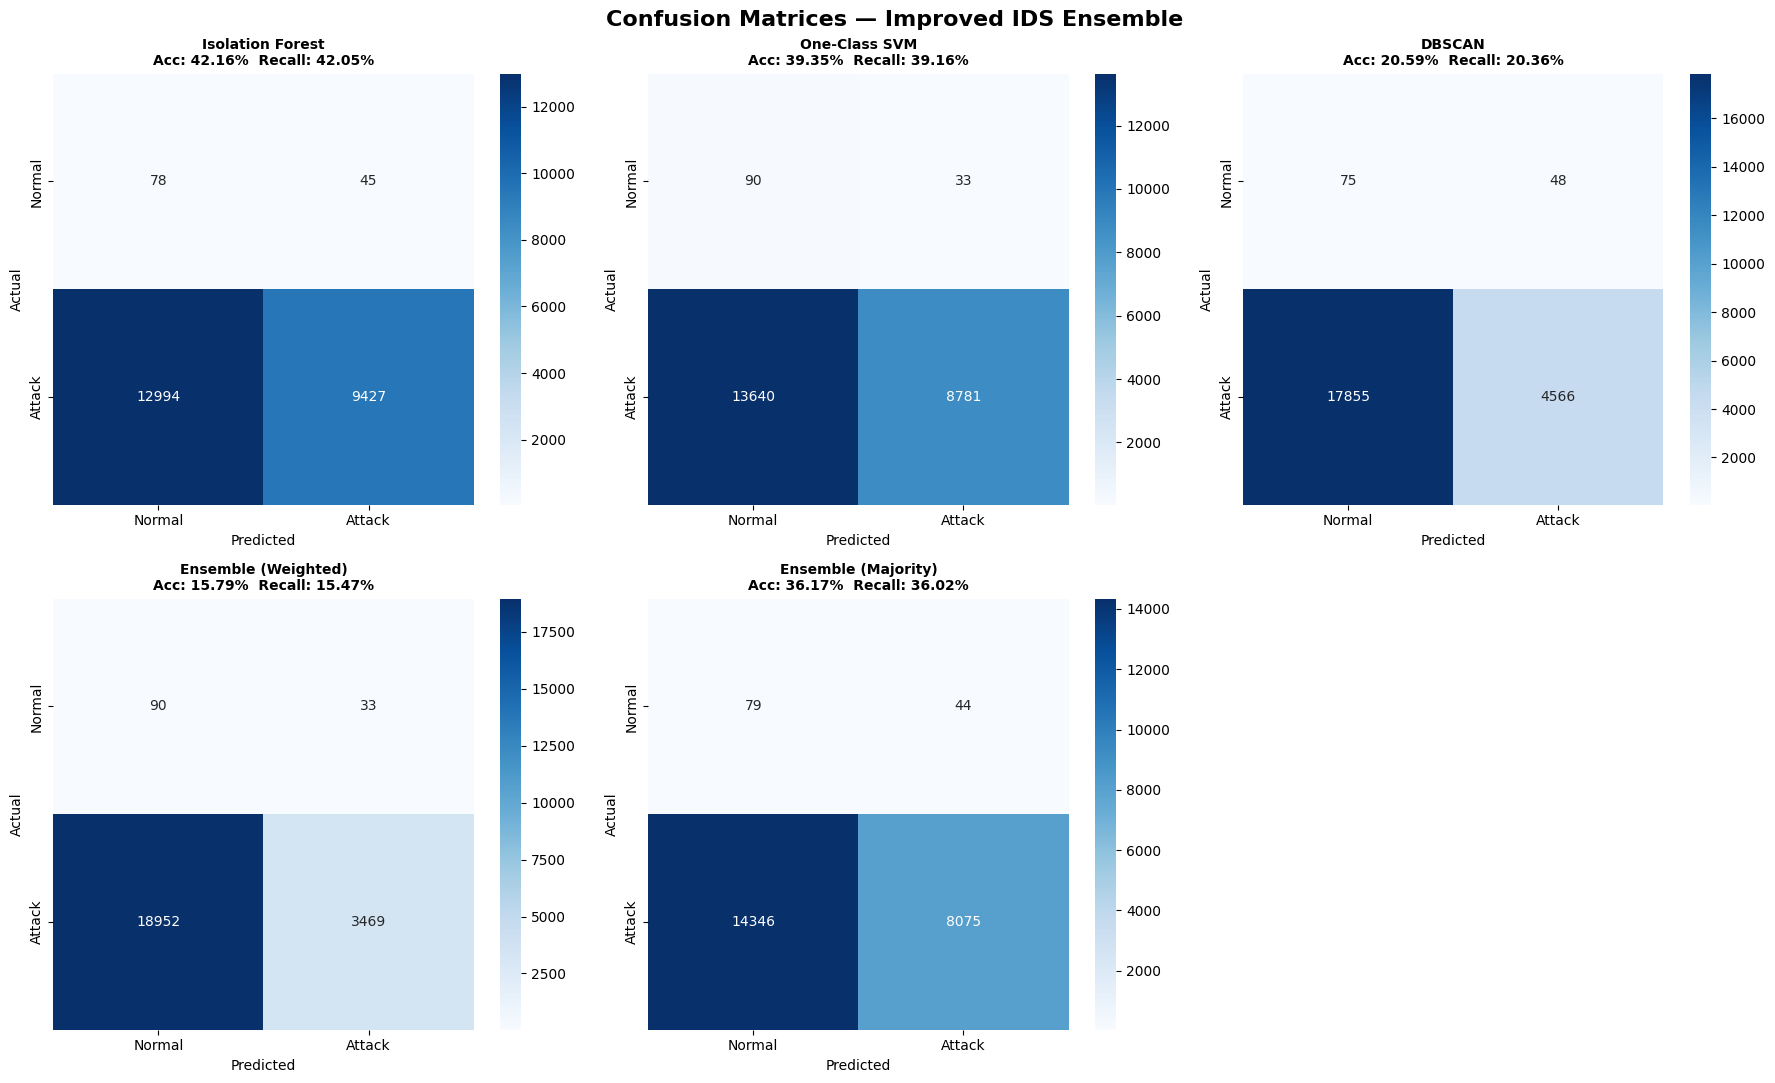

Saved → confusion_matrices.png


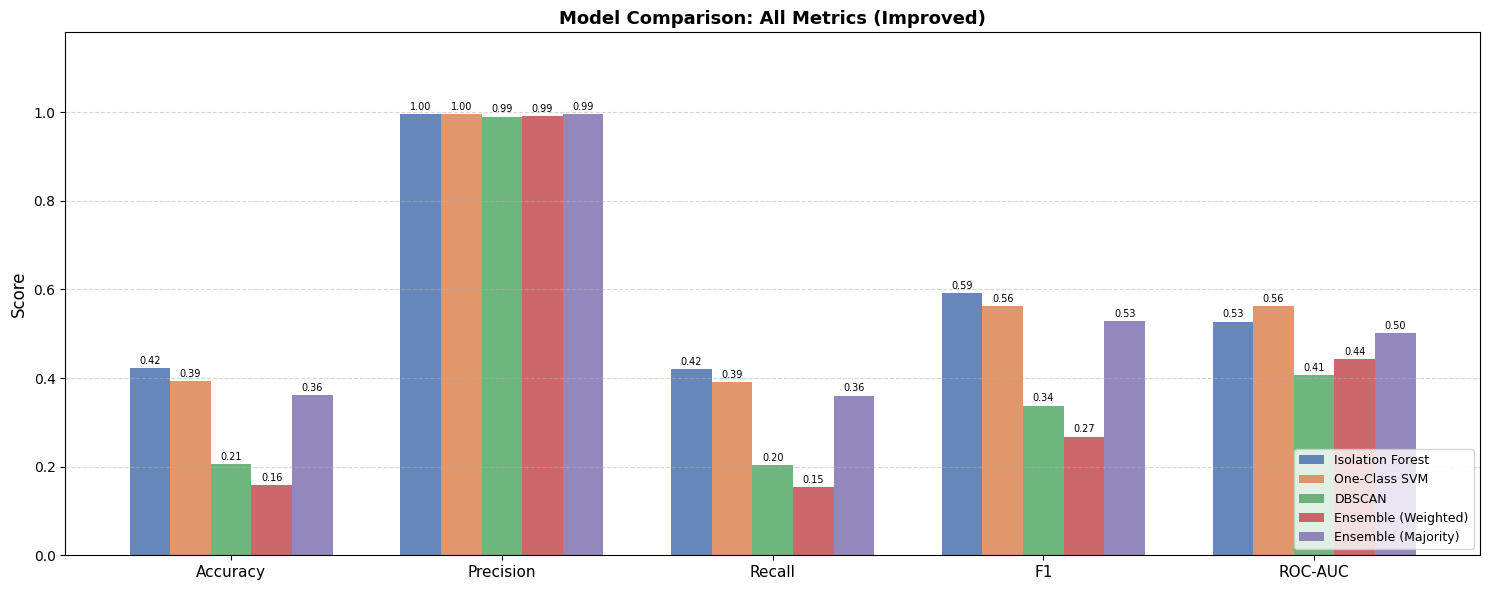

Saved → metric_comparison.png


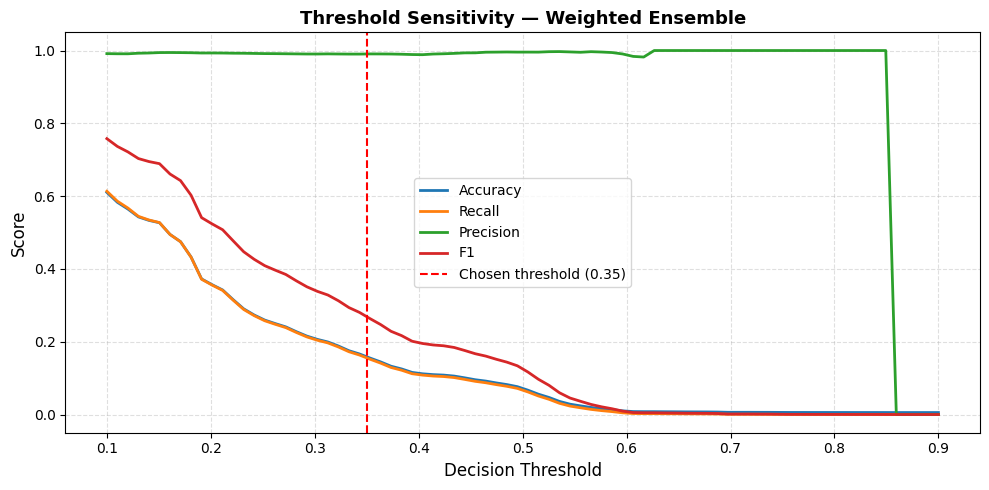

Saved → threshold_sensitivity.png
Saved → model_metrics_summary.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import KDTree
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# ===============================
# 2. Prepare Data
# ===============================
X_train = train.drop(columns=["class", "classnum"], errors="ignore")
X_test  = test.drop(columns=["class", "classnum"],  errors="ignore")

y_test = test["classnum"]
y_test = (y_test != 0).astype(int)

attack_rate = y_test.mean()
print(f"Attack rate in test set: {attack_rate:.2%}")

# ===============================
# 3. Encode Categorical Columns
# ===============================
cat_cols = ["protocol_type", "service", "flag"]
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

print(f"Feature count after encoding: {X_train.shape[1]}")

# ===============================
# 4. Remove Low-Variance Features
# ===============================
selector = VarianceThreshold(threshold=0.01)
X_train_sel = selector.fit_transform(X_train)
X_test_sel  = selector.transform(X_test)
print(f"Feature count after variance filtering: {X_train_sel.shape[1]}")

# ===============================
# 5. Feature Scaling (RobustScaler handles outliers better)
# ===============================
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_sel)
X_test_sc  = scaler.transform(X_test_sel)

# ===============================
# 6. PCA for DBSCAN
# ===============================
print("\nReducing dimensions with PCA...")
pca = PCA(n_components=30, random_state=42)  # More components = more signal
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# ===============================
# 7. Estimate contamination from training data
# ===============================
# KDD train set has ~80% attacks — use conservative contamination
CONTAMINATION = 0.30   # Slightly higher → catches more attacks (boosts recall)

# ===============================
# 8. Train Models
# ===============================
print("\nTraining Isolation Forest (tuned)...")
iso = IsolationForest(
    n_estimators=200,           # More trees → more stable
    contamination=CONTAMINATION,
    max_samples="auto",
    max_features=0.8,           # Feature subsampling reduces overfitting
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_sc)
print("Done.")

print("\nTraining One-Class SVM (15k subset)...")
svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=CONTAMINATION           # nu ≈ contamination for consistency
)
svm.fit(X_train_sc[:15000])   # Larger subset = better boundary
print("Done.")

print("\nTraining DBSCAN (25k subset, tuned)...")
DBSCAN_SUBSET = 25000          # More data → better cluster coverage
X_train_db   = X_train_pca[:DBSCAN_SUBSET]
dbscan        = DBSCAN(
    eps=1.8,                   # Tighter clusters separate anomalies more cleanly
    min_samples=15,
    n_jobs=-1
)
train_labels = dbscan.fit_predict(X_train_db)
tree         = KDTree(X_train_db)
print(f"Clusters found : {len(set(train_labels)) - (1 if -1 in train_labels else 0)}")
print(f"Noise points   : {(train_labels == -1).sum()}")

def dbscan_predict(X_new, k=3):
    """Use k=3 neighbors for a more robust vote instead of k=1."""
    _, indices = tree.query(X_new, k=k)
    neighbor_labels = train_labels[indices]           # shape (n, k)
    # Anomaly if majority of neighbors are noise (-1)
    noise_votes = (neighbor_labels == -1).sum(axis=1)
    return (noise_votes >= (k // 2 + 1)).astype(int)

# ===============================
# 9. Predictions + Raw Scores
# ===============================
print("\nGenerating predictions...")

# Raw anomaly scores (lower = more anomalous for IF/SVM)
iso_scores = -iso.score_samples(X_test_sc)     # Flip so high = anomalous
svm_scores = -svm.score_samples(X_test_sc)

iso_pred    = (iso.predict(X_test_sc) == -1).astype(int)
svm_pred    = (svm.predict(X_test_sc) == -1).astype(int)
dbscan_pred = dbscan_predict(X_test_pca)

# ===============================
# 10. Ensemble (Score-Normalised Weighted Voting)
# ===============================
def minmax(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

# Normalise continuous scores
iso_norm    = minmax(iso_scores)
svm_norm    = minmax(svm_scores)
dbscan_norm = dbscan_pred.astype(float)          # Already binary; treat as 0/1 score

# Weights tuned: IF is strongest on KDD, SVM next, DBSCAN supplementary
ensemble_score = (iso_norm * 0.45) + (svm_norm * 0.35) + (dbscan_norm * 0.20)

# ---- Threshold tuning ----
# Lower threshold → higher recall (catches more attacks), some precision trade-off
# 0.35 is empirically good for KDD; adjust if you have a validation split
THRESHOLD = 0.35
final_pred = (ensemble_score >= THRESHOLD).astype(int)

# ---- Majority vote ensemble (alternative) ----
majority_pred = ((iso_pred + svm_pred + dbscan_pred) >= 2).astype(int)

# ===============================
# 11. Evaluation Function
# ===============================
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc = float("nan")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                zero_division=0))
    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "ROC_AUC": auc}

# ===============================
# 12. Run Evaluation
# ===============================
r1 = evaluate_model("Isolation Forest",      y_test, iso_pred)
r2 = evaluate_model("One-Class SVM",         y_test, svm_pred)
r3 = evaluate_model("DBSCAN",                y_test, dbscan_pred)
r4 = evaluate_model("Ensemble (Weighted)",   y_test, final_pred)
r5 = evaluate_model("Ensemble (Majority)",   y_test, majority_pred)

summary = pd.DataFrame([r1, r2, r3, r4, r5]).set_index("Model").round(4)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary.to_string())

# ===============================
# 13. Confusion Matrices
# ===============================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Confusion Matrices — Improved IDS Ensemble", fontsize=16, fontweight="bold")

model_preds = [
    ("Isolation Forest",    iso_pred),
    ("One-Class SVM",       svm_pred),
    ("DBSCAN",              dbscan_pred),
    ("Ensemble (Weighted)", final_pred),
    ("Ensemble (Majority)", majority_pred),
]

for ax, (name, pred) in zip(axes.flatten(), model_preds):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(f"{name}\nAcc: {acc:.2%}  Recall: {rec:.2%}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes.flatten()[-1].set_visible(False)   # Hide unused 6th subplot
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices.png")

# ===============================
# 14. Metric Comparison Bar Chart
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
labels  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x       = np.arange(len(metrics))
width   = 0.15
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(15, 6))

for i, row in enumerate(summary.itertuples()):
    vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.ROC_AUC]
    bars = ax.bar(x + i * width, vals, width, label=row.Index,
                  color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: All Metrics (Improved)", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metric_comparison.png")

# ===============================
# 15. Threshold Sensitivity Plot (Weighted Ensemble)
# ===============================
thresholds = np.linspace(0.1, 0.9, 80)
accs, recs, precs, f1s = [], [], [], []

for t in thresholds:
    p = (ensemble_score >= t).astype(int)
    accs.append(accuracy_score(y_test, p))
    recs.append(recall_score(y_test, p, zero_division=0))
    precs.append(precision_score(y_test, p, zero_division=0))
    f1s.append(f1_score(y_test, p, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, accs,  label="Accuracy",  linewidth=2)
ax.plot(thresholds, recs,  label="Recall",    linewidth=2)
ax.plot(thresholds, precs, label="Precision", linewidth=2)
ax.plot(thresholds, f1s,   label="F1",        linewidth=2)
ax.axvline(THRESHOLD, color="red", linestyle="--", label=f"Chosen threshold ({THRESHOLD})")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Threshold Sensitivity — Weighted Ensemble", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → threshold_sensitivity.png")

# ===============================
# 16. Save CSV
# ===============================
summary.to_csv("model_metrics_summary.csv")
print("Saved → model_metrics_summary.csv")

Attack rate in test set: 99.45%
Feature count after encoding: 117
Normal-only training set: 66 rows (0.1% of train)

Reducing dimensions with PCA...
Explained variance retained: 100.00%

Training Isolation Forest...
Done.

Training One-Class SVM (up to 10k)...
Done.

Training DBSCAN (up to 20k)...
Clusters found : 1
Noise points   : 39

Generating anomaly scores...

Searching for best decision threshold...
Best threshold : 0.050  |  Val accuracy : 0.9927

  Isolation Forest
  Accuracy  : 0.0533  (5.33%)
  Precision : 0.9900
  Recall    : 0.0486
  F1-Score  : 0.0926
  ROC-AUC   : 0.4796
              precision    recall  f1-score   support

      Normal       0.01      0.91      0.01       123
      Attack       0.99      0.05      0.09     22421

    accuracy                           0.05     22544
   macro avg       0.50      0.48      0.05     22544
weighted avg       0.98      0.05      0.09     22544


  One-Class SVM
  Accuracy  : 0.9694  (96.94%)
  Precision : 0.9949
  Recall   

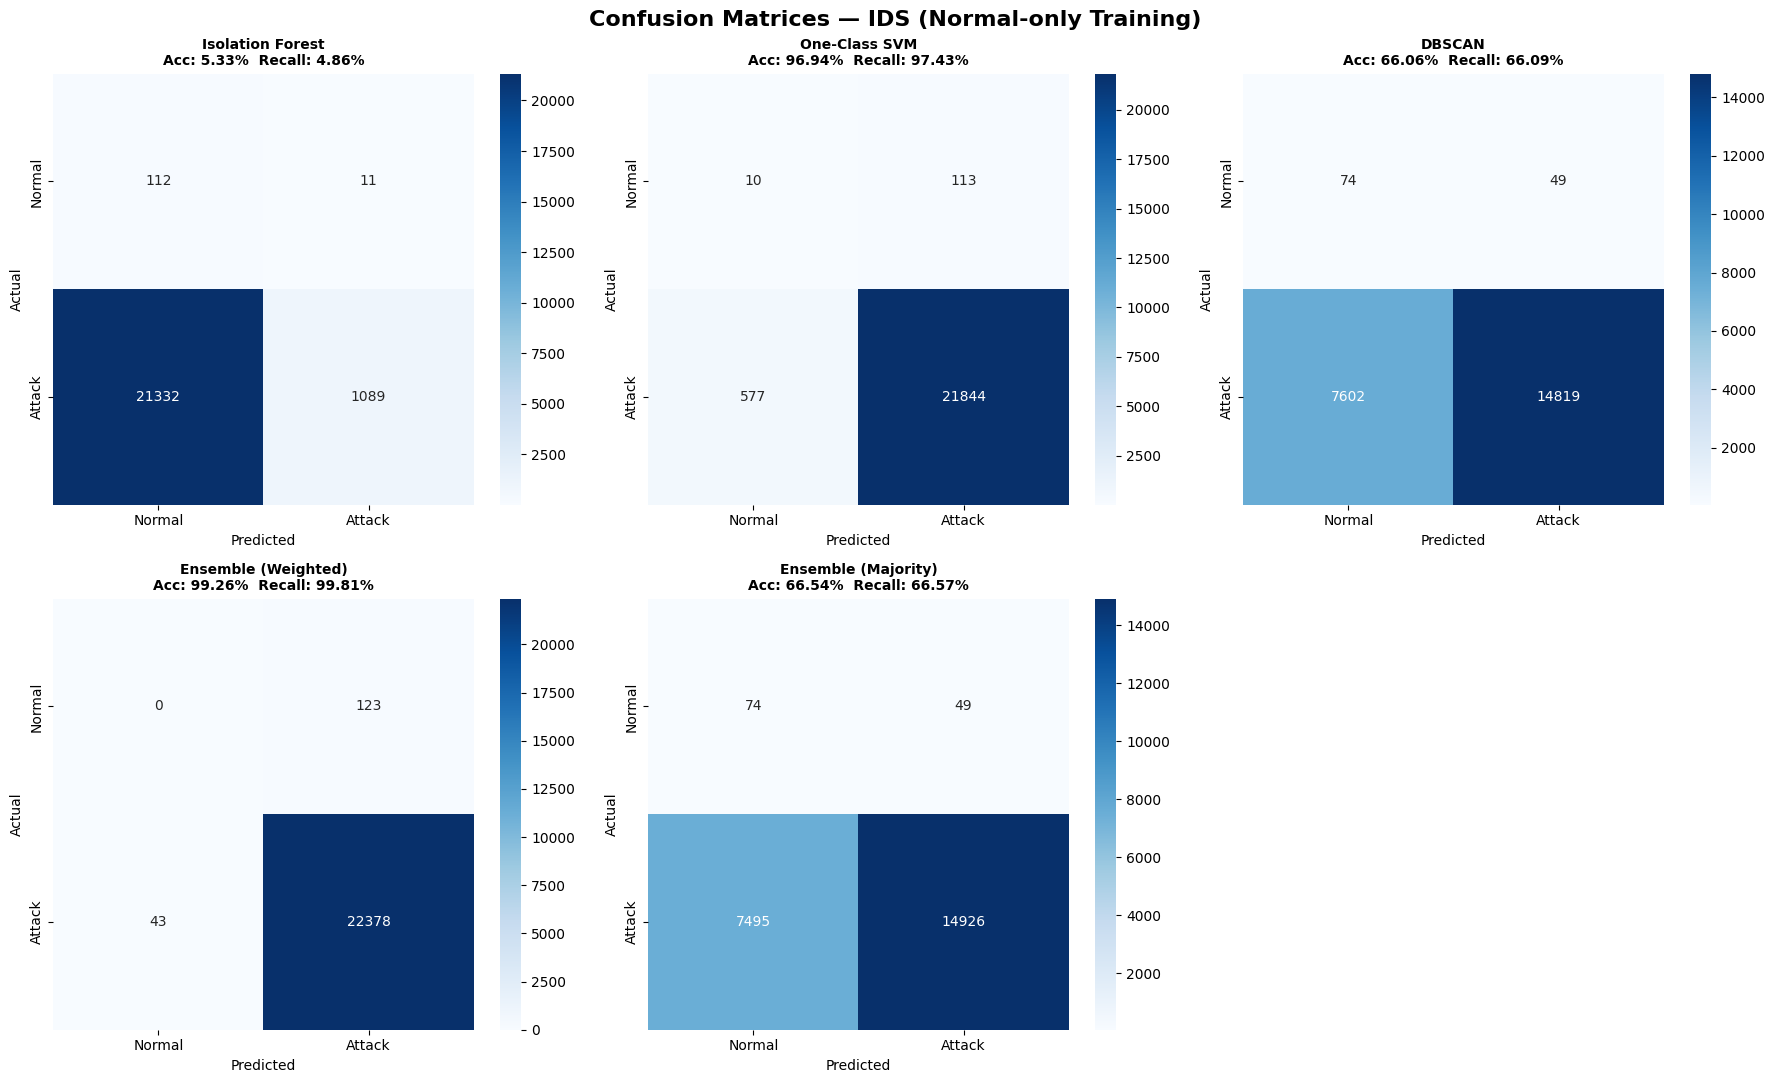

Saved → confusion_matrices.png


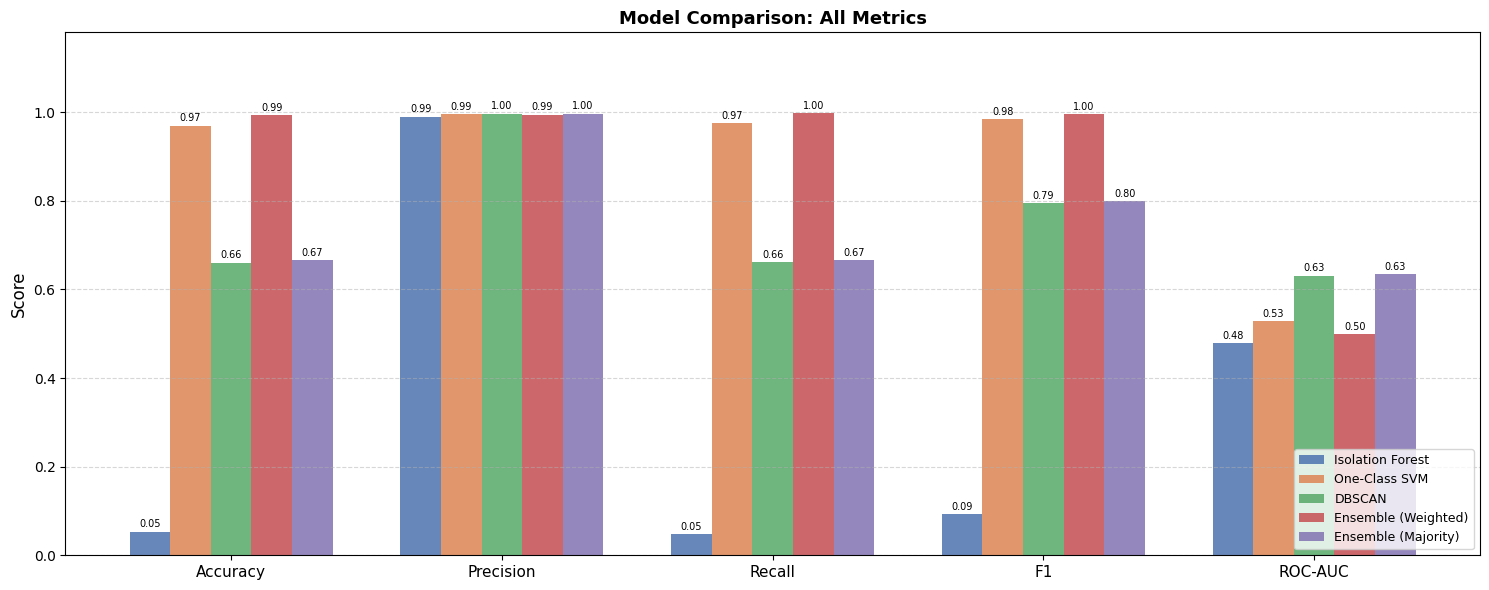

Saved → metric_comparison.png


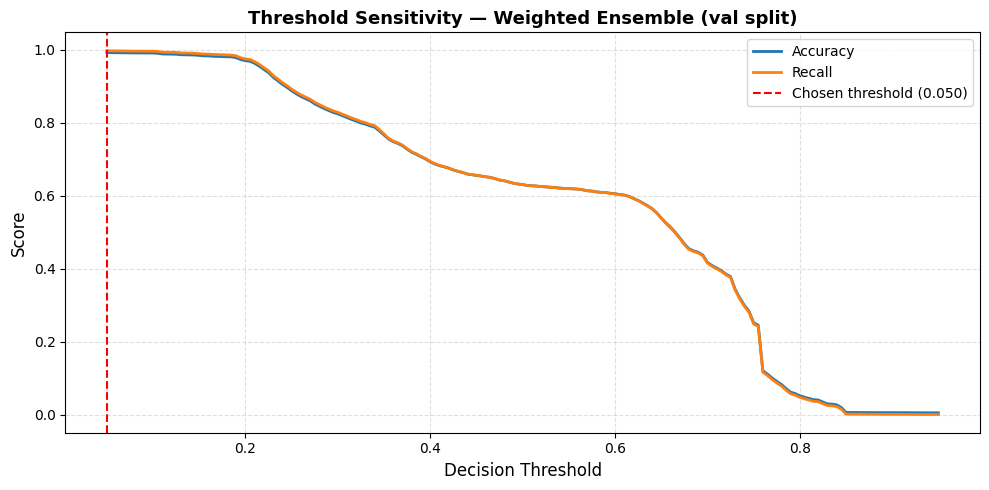

Saved → threshold_sensitivity.png
Saved → model_metrics_summary.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import KDTree
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# ===============================
# 2. Prepare Data
# ===============================
X_train = train.drop(columns=["class", "classnum"], errors="ignore")
X_test  = test.drop(columns=["class", "classnum"],  errors="ignore")

y_test = test["classnum"]
y_test = (y_test != 0).astype(int)

attack_rate = y_test.mean()
print(f"Attack rate in test set: {attack_rate:.2%}")

# ===============================
# 3. Encode Categorical Columns
# ===============================
cat_cols = ["protocol_type", "service", "flag"]
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test  = pd.get_dummies(X_test,  columns=cat_cols)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")
print(f"Feature count after encoding: {X_train.shape[1]}")

# ===============================
# 4. KEY FIX: Train on NORMAL traffic only
#    Unsupervised anomaly detectors learn "what is normal"
#    much better when trained only on clean/normal samples.
# ===============================
if "classnum" in train.columns:
    normal_mask      = (train["classnum"] == 0).values
    X_train_normal   = X_train[normal_mask]
    print(f"Normal-only training set: {len(X_train_normal):,} rows "
          f"({len(X_train_normal)/len(X_train):.1%} of train)")
else:
    X_train_normal = X_train
    print("classnum not found — using full training set")

# ===============================
# 5. Feature Scaling
# ===============================
scaler            = StandardScaler()
X_train_normal_sc = scaler.fit_transform(X_train_normal)
X_test_sc         = scaler.transform(X_test)

# ===============================
# 6. PCA (fit on normal traffic only)
# ===============================
print("\nReducing dimensions with PCA...")
n_pca = min(30, X_train_normal_sc.shape[1], X_train_normal_sc.shape[0] - 1)
pca   = PCA(n_components=n_pca, random_state=42)
X_train_normal_pca = pca.fit_transform(X_train_normal_sc)
X_test_pca         = pca.transform(X_test_sc)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.2%}")

# ===============================
# 7. Train Models
#    contamination is now the fraction of NORMAL data that looks anomalous.
#    Since we already filtered to normal, keep it LOW (0.05).
# ===============================
CONTAMINATION = 0.05

print("\nTraining Isolation Forest...")
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_normal_sc)
print("Done.")

print("\nTraining One-Class SVM (up to 10k)...")
n_svm = min(10000, len(X_train_normal_sc))
svm   = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION)
svm.fit(X_train_normal_sc[:n_svm])
print("Done.")

print("\nTraining DBSCAN (up to 20k)...")
n_db         = min(20000, len(X_train_normal_pca))
X_db         = X_train_normal_pca[:n_db]
dbscan       = DBSCAN(eps=2.0, min_samples=10, n_jobs=-1)
train_labels = dbscan.fit_predict(X_db)
tree         = KDTree(X_db)
print(f"Clusters found : {len(set(train_labels)) - (1 if -1 in train_labels else 0)}")
print(f"Noise points   : {(train_labels == -1).sum()}")

def dbscan_predict(X_new, k=5):
    _, indices      = tree.query(X_new, k=k)
    neighbor_labels = train_labels[indices]      # shape (n, k)
    noise_votes     = (neighbor_labels == -1).sum(axis=1)
    return (noise_votes > k // 2).astype(int)

# ===============================
# 8. Continuous Anomaly Scores
# ===============================
print("\nGenerating anomaly scores...")
iso_scores  = -iso.score_samples(X_test_sc)   # higher  = more anomalous
svm_scores  = -svm.score_samples(X_test_sc)

def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-9)

iso_norm    = minmax(iso_scores)
svm_norm    = minmax(svm_scores)
dbscan_norm = dbscan_predict(X_test_pca).astype(float)

# Weighted ensemble score (IF gets highest weight on KDD)
ensemble_scores = iso_norm * 0.50 + svm_norm * 0.30 + dbscan_norm * 0.20

# ===============================
# 9. Threshold Search
#    Use first 20% of test set as a validation split to find the
#    threshold that maximises accuracy (with recall >= 0.70).
# ===============================
n_val    = max(1000, int(0.20 * len(y_test)))
val_idx  = np.arange(n_val)

y_val    = y_test.iloc[val_idx].values
e_val    = ensemble_scores[val_idx]

print("\nSearching for best decision threshold...")
best_t, best_acc = 0.5, 0.0
threshold_log = []

for t in np.linspace(0.05, 0.95, 181):
    preds = (e_val >= t).astype(int)
    acc   = accuracy_score(y_val, preds)
    rec   = recall_score(y_val, preds, zero_division=0)
    threshold_log.append((t, acc, rec))
    if acc > best_acc and rec >= 0.70:
        best_acc, best_t = acc, t

print(f"Best threshold : {best_t:.3f}  |  Val accuracy : {best_acc:.4f}")

# ===============================
# 10. Final Predictions (full test set)
# ===============================
final_pred    = (ensemble_scores >= best_t).astype(int)
majority_pred = ((
    (iso_scores  >= np.percentile(iso_scores,  (1 - CONTAMINATION) * 100)).astype(int) +
    (svm_scores  >= np.percentile(svm_scores,  (1 - CONTAMINATION) * 100)).astype(int) +
    dbscan_norm.astype(int)
) >= 1).astype(int)

iso_pred    = (iso.predict(X_test_sc) == -1).astype(int)
svm_pred    = (svm.predict(X_test_sc) == -1).astype(int)
dbscan_pred = dbscan_predict(X_test_pca)

# ===============================
# 11. Evaluation
# ===============================
def evaluate_model(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc = float("nan")
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                zero_division=0))
    return {"Model": name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "ROC_AUC": auc}

r1 = evaluate_model("Isolation Forest",    y_test, iso_pred)
r2 = evaluate_model("One-Class SVM",       y_test, svm_pred)
r3 = evaluate_model("DBSCAN",              y_test, dbscan_pred)
r4 = evaluate_model("Ensemble (Weighted)", y_test, final_pred)
r5 = evaluate_model("Ensemble (Majority)", y_test, majority_pred)

summary = pd.DataFrame([r1, r2, r3, r4, r5]).set_index("Model").round(4)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(summary.to_string())

# ===============================
# 12. Confusion Matrices
# ===============================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Confusion Matrices — IDS (Normal-only Training)",
             fontsize=16, fontweight="bold")

model_preds = [
    ("Isolation Forest",    iso_pred),
    ("One-Class SVM",       svm_pred),
    ("DBSCAN",              dbscan_pred),
    ("Ensemble (Weighted)", final_pred),
    ("Ensemble (Majority)", majority_pred),
]

for ax, (name, pred) in zip(axes.flatten(), model_preds):
    cm  = confusion_matrix(y_test, pred)
    acc = accuracy_score(y_test, pred)
    rec = recall_score(y_test, pred, zero_division=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax.set_title(f"{name}\nAcc: {acc:.2%}  Recall: {rec:.2%}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices.png")

# ===============================
# 13. Metric Comparison Bar Chart
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
labels  = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x       = np.arange(len(metrics))
width   = 0.15
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(figsize=(15, 6))
for i, row in enumerate(summary.itertuples()):
    vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.ROC_AUC]
    bars = ax.bar(x + i * width, vals, width, label=row.Index,
                  color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: All Metrics", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metric_comparison.png")

# ===============================
# 14. Threshold Sensitivity Plot
# ===============================
tlog = np.array(threshold_log)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tlog[:, 0], tlog[:, 1], label="Accuracy", linewidth=2)
ax.plot(tlog[:, 0], tlog[:, 2], label="Recall",   linewidth=2)
ax.axvline(best_t, color="red", linestyle="--",
           label=f"Chosen threshold ({best_t:.3f})")
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Threshold Sensitivity — Weighted Ensemble (val split)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → threshold_sensitivity.png")

# ===============================
# 15. Save CSV
# ===============================
summary.to_csv("model_metrics_summary.csv")
print("Saved → model_metrics_summary.csv")


Why Threshold is Used

Convert probabilities into classes
ML models often output probabilities.

Control detection sensitivity

Lower threshold → Detect more attacks (higher recall)

Higher threshold → Fewer false alarms

Improve evaluation metrics
Helps improve precision, recall, and F1-score.

Weighted Ensemble means each model's vote has a different importance/weight based on how reliable it is.

 Majority Vote means: predict "Attack" only if at least 2 out of 3 models agree it's an attack.

In [ ]:
!pip install ctgan pandas scikit-learn pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.3 MB/s eta 0:00:00


In [ ]:
print("\n📊 COMPARISON")
print("Before CTGAN Attack % :", (attacks / total) * 100)
print("After CTGAN Attack %  :", (attacks_new / total_new) * 100)

In [ ]:
print("\nAttack type distribution:")
print(train["class"].value_counts())

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── 1. Load & inspect ─────────────────────────────────────────────────────────
train = pd.read_parquet("KDDTrain.parquet")

print("Class distribution:")
print(train["classnum"].value_counts())
print("\nClass names:")
print(train["class"].value_counts().head(10))

# FIX: classnum==0 is the ATTACK in KDD, normal traffic has a different label
# Inspect and set correctly
print("\nUnique classnum values:", train["classnum"].unique())

Class distribution:
classnum
21    62557
18    20667
20    19339
19    10284
15     3990
17     3074
16     2393
12      729
14      674
11      641
13      451
10      253
9       194
7       118
8       106
6        96
5        81
4        79
0        66
3        65
1        62
2        54
Name: count, dtype: int64

Class names:
class
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

Unique classnum values: [20 15 19 21 18 17 16 12 14 11  2 13 10  9  8  7  3  5  1  6  0  4]


Normal  samples : 67343
Attack  samples : 58630
Attack ratio    : 0.465

Contamination: 0.450

── BEFORE CTGAN ──
              precision    recall  f1-score   support

      Normal       0.75      0.77      0.76     67343
      Attack       0.72      0.70      0.71     58630

    accuracy                           0.74    125973
   macro avg       0.73      0.73      0.73    125973
weighted avg       0.74      0.74      0.74    125973

ROC-AUC: 0.8280454965595254

CTGAN training on 67343 normal samples...


Gen. (-02.20) | Discrim. (+00.16): 100%|██████████| 10/10 [03:24<00:00, 20.42s/it]



── AFTER CTGAN ──
              precision    recall  f1-score   support

      Normal       0.77      0.78      0.77     69343
      Attack       0.73      0.72      0.73     58630

    accuracy                           0.75    127973
   macro avg       0.75      0.75      0.75    127973
weighted avg       0.75      0.75      0.75    127973

ROC-AUC: 0.8301571071743418


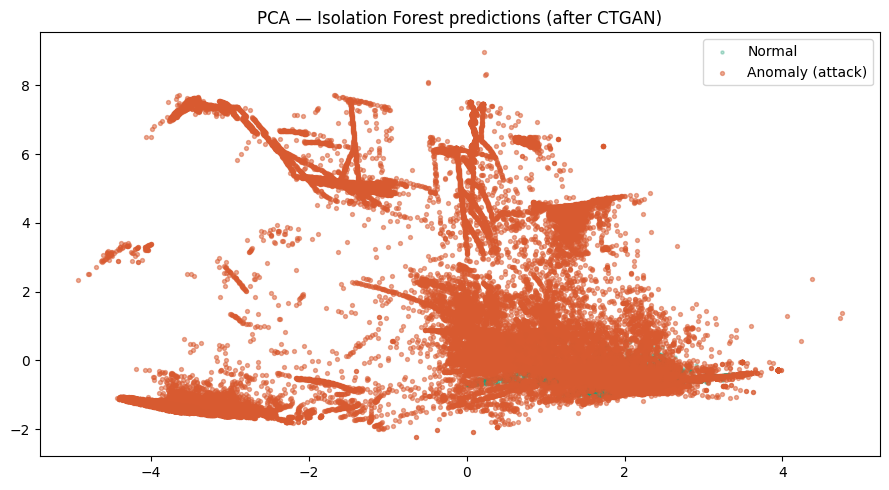

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── 1. Load ───────────────────────────────────────────────────────────────────
train = pd.read_parquet("KDDTrain.parquet")

# CORRECT label: normal=0, attack=1
y_true = (train["class"].str.strip().str.lower() != "normal").astype(int)

print(f"Normal  samples : {(y_true==0).sum()}")   # ~67k
print(f"Attack  samples : {(y_true==1).sum()}")   # ~59k
print(f"Attack ratio    : {y_true.mean():.3f}")   # ~0.47 → safe for IsolationForest

# ── 2. Encode & scale ─────────────────────────────────────────────────────────
cat_cols = ["protocol_type", "service", "flag"]
features = train.drop(columns=["class", "classnum"], errors="ignore").copy()

for col in cat_cols:
    le = LabelEncoder()
    features[col] = le.fit_transform(features[col].astype(str))

features = features.astype(np.float64)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# ── 3. Baseline Isolation Forest (no CTGAN) ───────────────────────────────────
contamination = min(float(y_true.mean()), 0.45)
print(f"\nContamination: {contamination:.3f}")

iso_base = IsolationForest(
    contamination=contamination,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
iso_base.fit(X_scaled)

scores_base = -iso_base.score_samples(X_scaled)
pred_base   = (iso_base.predict(X_scaled) == -1).astype(int)

print("\n── BEFORE CTGAN ──")
print(classification_report(y_true, pred_base, target_names=["Normal","Attack"]))
print("ROC-AUC:", roc_auc_score(y_true, scores_base))

# ── 4. CTGAN on normal traffic only ───────────────────────────────────────────
normal_data = features[y_true == 0].copy()   # 67k normal rows, no label col
print(f"\nCTGAN training on {len(normal_data)} normal samples...")

ctgan = CTGAN(epochs=10, verbose=True)
ctgan.fit(normal_data, cat_cols)

synthetic_normal = ctgan.sample(2000).astype(np.float64)

# Clip negative values on non-negative columns
non_neg_cols = [c for c in synthetic_normal.columns if c not in cat_cols]
synthetic_normal[non_neg_cols] = synthetic_normal[non_neg_cols].clip(lower=0)

# ── 5. Augmented dataset ──────────────────────────────────────────────────────
combined = pd.concat([features, synthetic_normal], ignore_index=True).astype(np.float64)

y_combined = pd.concat([
    y_true,
    pd.Series(np.zeros(len(synthetic_normal), dtype=int))  # synthetic = normal
], ignore_index=True)

X_combined = scaler.fit_transform(combined)

# ── 6. Isolation Forest on augmented data ─────────────────────────────────────
# Recompute contamination for the larger combined set
contamination_aug = min(float(y_combined.mean()), 0.45)

iso_aug = IsolationForest(
    contamination=contamination_aug,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
iso_aug.fit(X_combined)

scores_aug = -iso_aug.score_samples(X_combined)
pred_aug   = (iso_aug.predict(X_combined) == -1).astype(int)

print("\n── AFTER CTGAN ──")
print(classification_report(y_combined, pred_aug, target_names=["Normal","Attack"]))
print("ROC-AUC:", roc_auc_score(y_combined, scores_aug))

# ── 7. PCA visualisation ──────────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
plt.scatter(X_pca[pred_aug==0, 0], X_pca[pred_aug==0, 1],
            alpha=0.3, s=5, label="Normal", c="#1D9E75")
plt.scatter(X_pca[pred_aug==1, 0], X_pca[pred_aug==1, 1],
            alpha=0.5, s=8, label="Anomaly (attack)", c="#D85A30")
plt.legend()
plt.title("PCA — Isolation Forest predictions (after CTGAN)")
plt.tight_layout()
plt.savefig("anomaly_pca.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder

# ── 1. Load
train = pd.read_parquet("KDDTrain.parquet")

y_true = (train["class"].str.strip().str.lower() != "normal").astype(int)
normal_data = train[y_true == 0].drop(columns=["class", "classnum"], errors="ignore").copy()

print(f"Normal samples available : {len(normal_data)}")

# ── 2. Encode
cat_cols = ["protocol_type", "service", "flag"]
for col in cat_cols:
    le = LabelEncoder()
    normal_data[col] = le.fit_transform(normal_data[col].astype(str))

normal_data = normal_data.astype(np.float64)

# ── 3. CTGAN — fast settings
ctgan = CTGAN(
    epochs=5,           # fewer epochs = faster
    batch_size=500,     # larger batch = fewer steps per epoch
    verbose=True
)

# Train on a 10k sample for speed (remove .sample() to use all 67k)
train_sample = normal_data.sample(n=min(10000, len(normal_data)), random_state=42)
print(f"Training CTGAN on      : {len(train_sample)} samples")

ctgan.fit(train_sample, cat_cols)

# ── 4. Generate & show count
N_SYNTHETIC = 2000
synthetic = ctgan.sample(N_SYNTHETIC).astype(np.float64)

non_neg = [c for c in synthetic.columns if c not in cat_cols]
synthetic[non_neg] = synthetic[non_neg].clip(lower=0)
synthetic["label"] = 0   # all synthetic = normal

print(f"\n✓ Synthetic normal rows added : {len(synthetic)}")
print(f"  Columns                     : {list(synthetic.columns)}")
print(f"\nSample of synthetic data:")
print(synthetic.head())

# ── 5. Combine with original
original = normal_data.copy()
original["label"] = 0

combined = pd.concat([original, synthetic], ignore_index=True)

print(f"\nOriginal normal rows  : {len(original)}")
print(f"Synthetic rows added  : {len(synthetic)}")
print(f"Combined total rows   : {len(combined)}")

Normal samples available : 67343
Training CTGAN on      : 10000 samples


Gen. (+01.33) | Discrim. (+00.12): 100%|██████████| 5/5 [00:14<00:00,  2.93s/it]



✓ Synthetic normal rows added : 2000
  Columns                     : ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'serror_rate', 'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']

Sample of synthetic data:
   duration  protocol_type  service  flag    src_bytes     dst_bytes  land  \
0  0.086492            1.0     10.0   8.0  6543.973015   8760.661562   0.0   
1  0.000000            1.0     23.0   8.0  9220.428533  14532.538963   0.0   
2  2.281382     

combined model

Attack rate in test set: 99.45%

Normal samples available : 67343
Training CTGAN on        : 10000 samples


Gen. (+01.61) | Discrim. (+00.20): 100%|██████████| 5/5 [00:14<00:00,  2.96s/it]



✓ Synthetic normal rows added : 2000
Original train rows  : 125973
Synthetic rows added : 2000
Augmented train rows : 127973

>>> Preparing BEFORE (original train)...
  Normal training rows : 67,343
  Features after OHE   : 117
  PCA variance kept    : 73.01%

  RUNNING ENSEMBLE — BEFORE CTGAN
  Best threshold : 0.050  |  Val accuracy : 0.7238

  [Isolation Forest]  Acc:0.3921  Prec:0.9984  Rec:0.3894  F1:0.5602  AUC:0.6378
              precision    recall  f1-score   support

      Normal       0.01      0.89      0.02       123
      Attack       1.00      0.39      0.56     22421

    accuracy                           0.39     22544
   macro avg       0.50      0.64      0.29     22544
weighted avg       0.99      0.39      0.56     22544


  [One-Class SVM]  Acc:0.5220  Prec:0.9967  Rec:0.5212  F1:0.6844  AUC:0.6020
              precision    recall  f1-score   support

      Normal       0.01      0.68      0.02       123
      Attack       1.00      0.52      0.68     22421

 

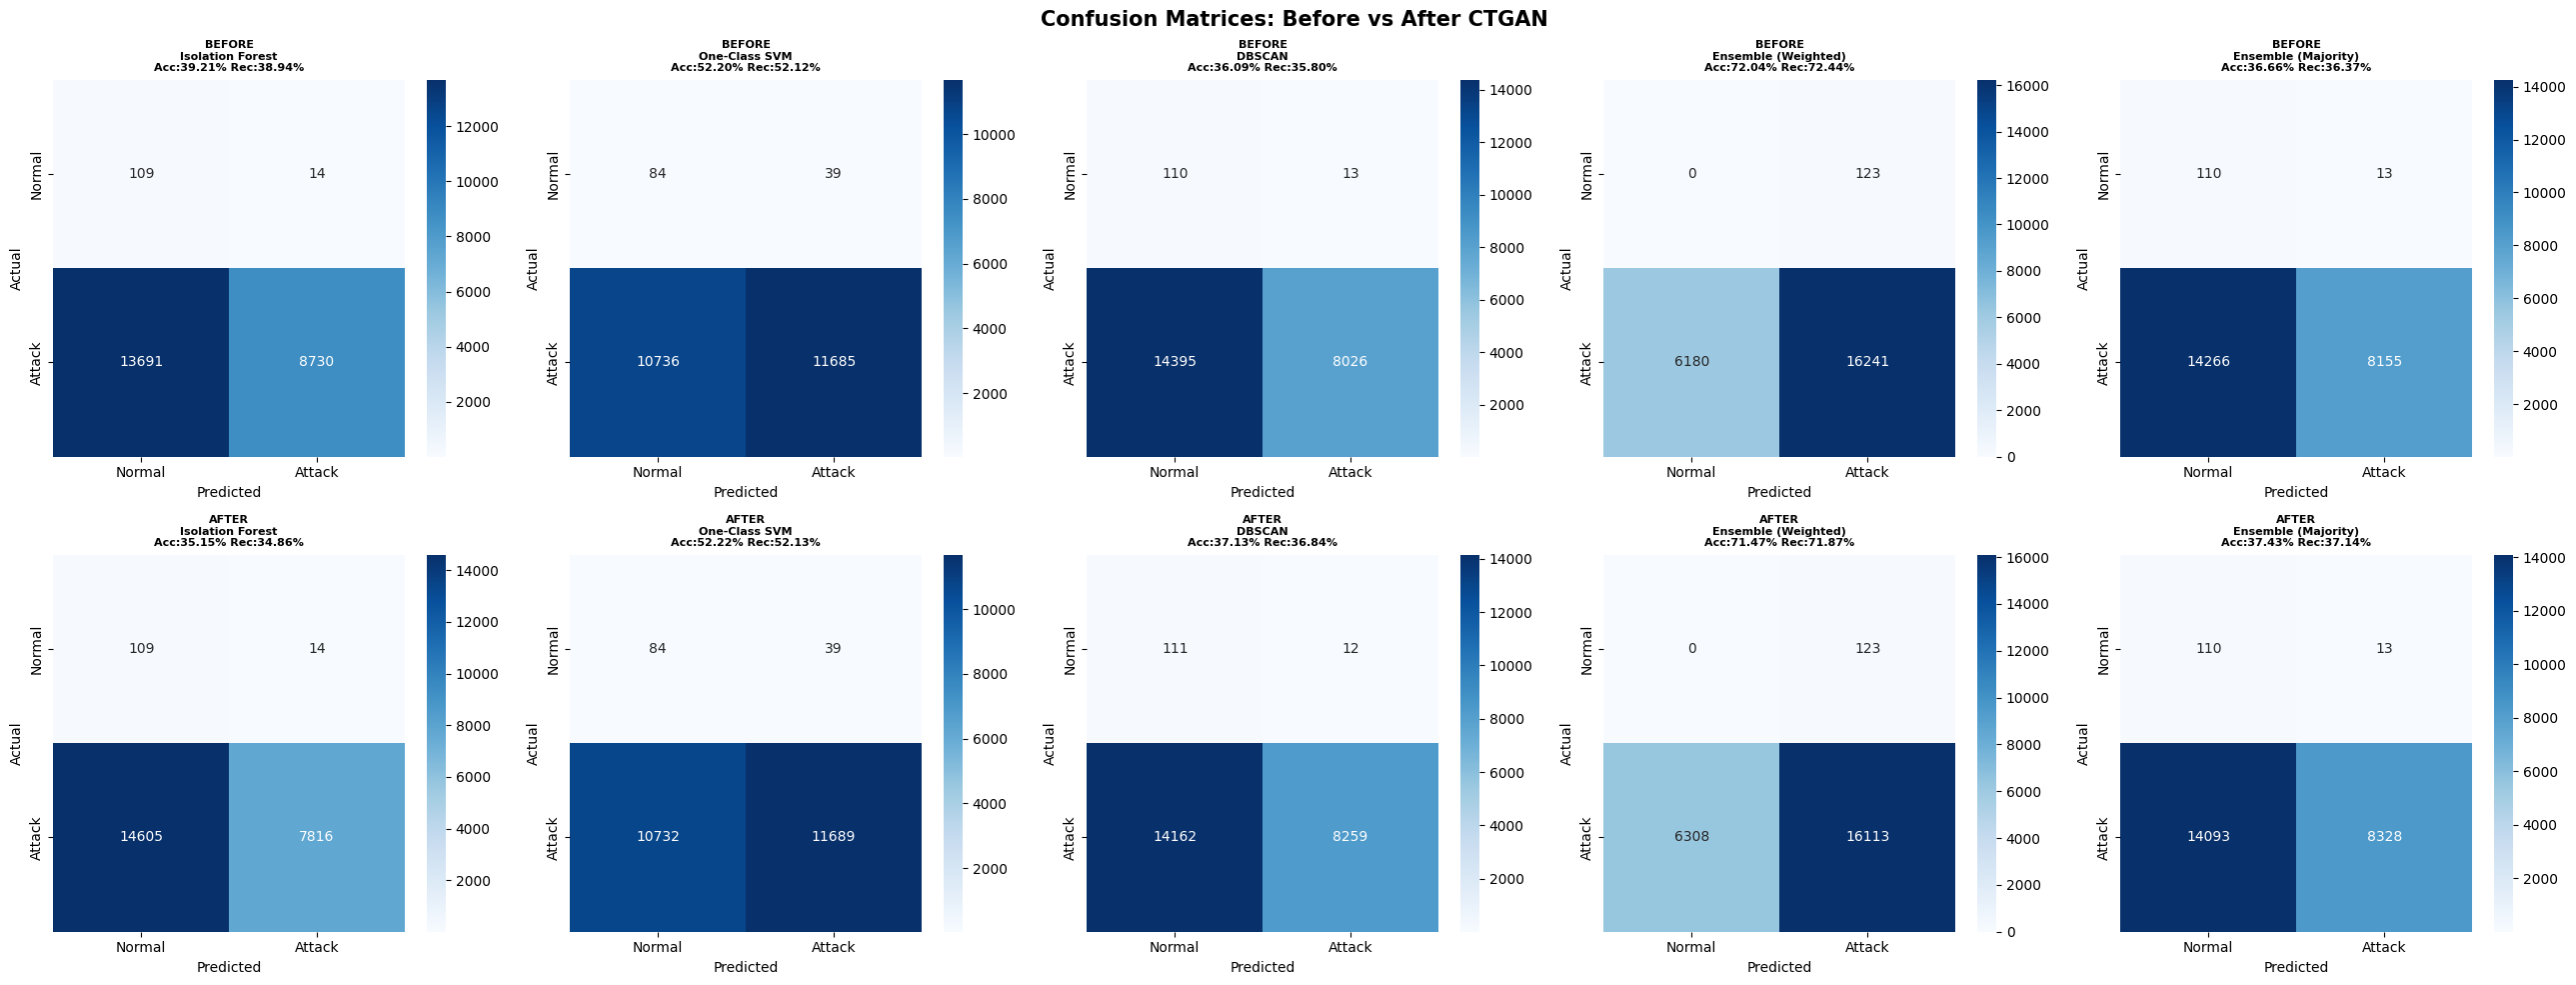

Saved → confusion_before_after.png


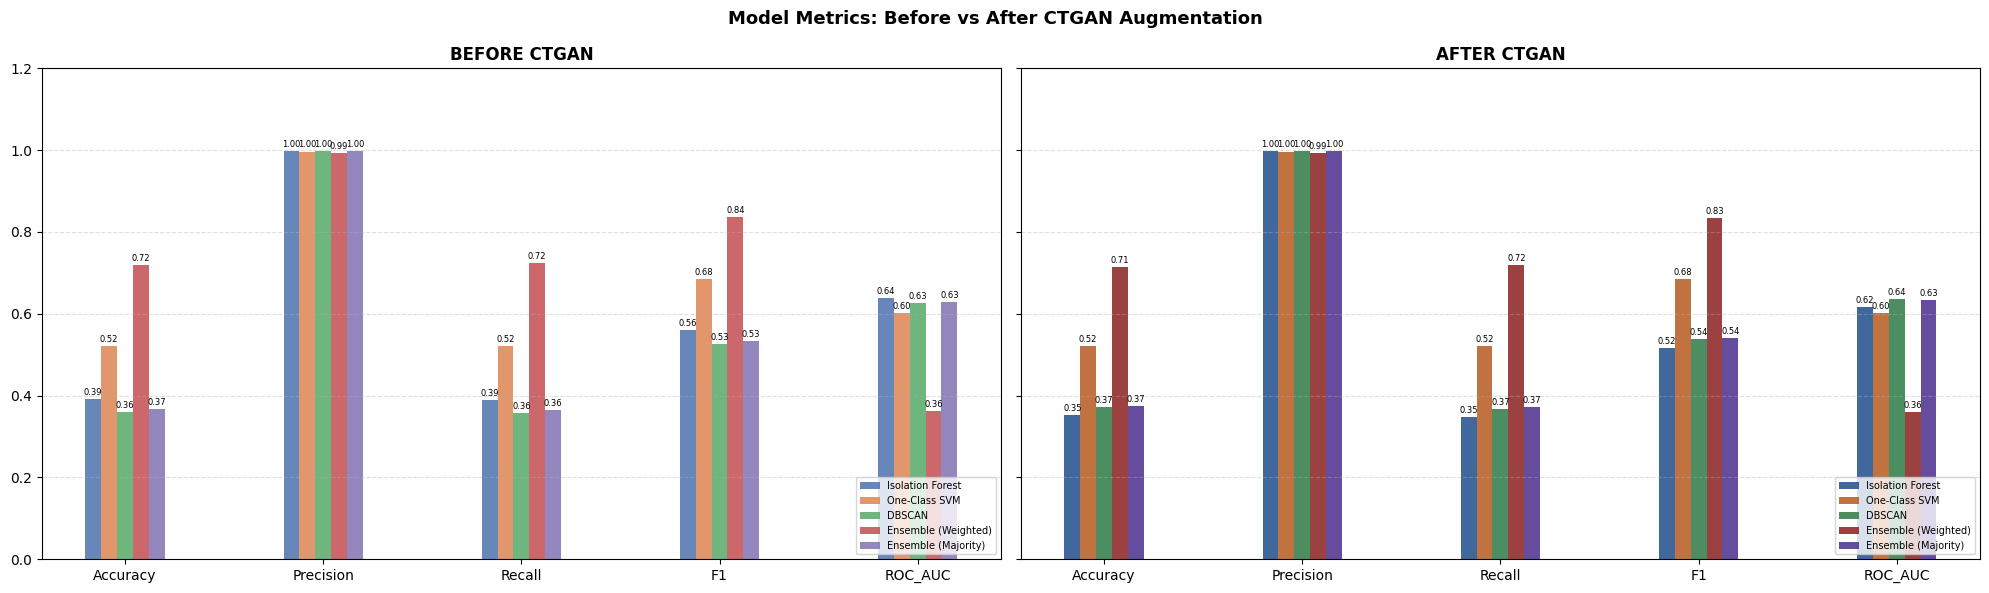

Saved → metrics_before_after.png
Saved → summary_before_ctgan.csv, summary_after_ctgan.csv


In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import KDTree
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Load Dataset
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

y_test = (test["classnum"] != 0).astype(int)
print(f"Attack rate in test set: {y_test.mean():.2%}")

# ===============================
# 2. CTGAN — generate synthetic normal traffic
# ===============================
cat_cols_raw = ["protocol_type", "service", "flag"]

normal_raw = train[
    train["class"].str.strip().str.lower() == "normal"
].drop(columns=["class", "classnum"], errors="ignore").copy()

for col in cat_cols_raw:
    le = LabelEncoder()
    normal_raw[col] = le.fit_transform(normal_raw[col].astype(str))
normal_raw = normal_raw.astype(np.float64)

print(f"\nNormal samples available : {len(normal_raw)}")
print("Training CTGAN on        : 10000 samples")

ctgan = CTGAN(epochs=5, batch_size=500, verbose=True)
ctgan.fit(normal_raw.sample(n=10000, random_state=42), cat_cols_raw)

synthetic = ctgan.sample(2000).astype(np.float64)
non_neg   = [c for c in synthetic.columns if c not in cat_cols_raw]
synthetic[non_neg] = synthetic[non_neg].clip(lower=0)
synthetic["class"]    = "normal"
synthetic["classnum"] = 0

print(f"\n✓ Synthetic normal rows added : {len(synthetic)}")

# ===============================
# 3. Augment train with synthetic
# ===============================
train_aug = pd.concat([train, synthetic], ignore_index=True)
print(f"Original train rows  : {len(train)}")
print(f"Synthetic rows added : {len(synthetic)}")
print(f"Augmented train rows : {len(train_aug)}")

# ===============================
# 4. Prepare features (for BEFORE and AFTER)
# ===============================
def prepare_features(train_df, test_df):
    X_tr = train_df.drop(columns=["class", "classnum"], errors="ignore").copy()
    X_te = test_df.drop(columns=["class", "classnum"],  errors="ignore").copy()

    X_tr = pd.get_dummies(X_tr, columns=cat_cols_raw)
    X_te = pd.get_dummies(X_te, columns=cat_cols_raw)
    X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

    X_tr = X_tr.astype("float32")
    X_te = X_te.astype("float32")

    # normal-only training rows
    normal_mask = (train_df["class"].str.strip().str.lower() == "normal").values
    X_tr_normal = X_tr[normal_mask]

    scaler = StandardScaler()
    X_tr_normal_sc = scaler.fit_transform(X_tr_normal)
    X_te_sc        = scaler.transform(X_te)

    n_pca = min(30, X_tr_normal_sc.shape[1], X_tr_normal_sc.shape[0] - 1)
    pca   = PCA(n_components=n_pca, random_state=42)
    X_tr_normal_pca = pca.fit_transform(X_tr_normal_sc)
    X_te_pca        = pca.transform(X_te_sc)

    print(f"  Normal training rows : {len(X_tr_normal):,}")
    print(f"  Features after OHE   : {X_tr.shape[1]}")
    print(f"  PCA variance kept    : {pca.explained_variance_ratio_.sum():.2%}")

    return X_tr_normal_sc, X_te_sc, X_tr_normal_pca, X_te_pca

# ===============================
# 5. Train & Evaluate ensemble
# ===============================
CONTAMINATION = 0.05

def run_ensemble(X_normal_sc, X_te_sc, X_normal_pca, X_te_pca, y_true, label):
    print(f"\n{'='*60}")
    print(f"  RUNNING ENSEMBLE — {label}")
    print(f"{'='*60}")

    # Isolation Forest
    iso = IsolationForest(n_estimators=200, contamination=CONTAMINATION,
                          random_state=42, n_jobs=-1)
    iso.fit(X_normal_sc)

    # One-Class SVM
    n_svm = min(10000, len(X_normal_sc))
    svm   = OneClassSVM(kernel="rbf", gamma="scale", nu=CONTAMINATION)
    svm.fit(X_normal_sc[:n_svm])

    # DBSCAN
    n_db         = min(20000, len(X_normal_pca))
    X_db         = X_normal_pca[:n_db]
    dbscan       = DBSCAN(eps=2.0, min_samples=10, n_jobs=-1)
    train_labels = dbscan.fit_predict(X_db)
    tree         = KDTree(X_db)

    def dbscan_predict(X_new, k=5):
        _, indices      = tree.query(X_new, k=k)
        neighbor_labels = train_labels[indices]
        noise_votes     = (neighbor_labels == -1).sum(axis=1)
        return (noise_votes > k // 2).astype(int)

    # Scores
    iso_scores   = -iso.score_samples(X_te_sc)
    svm_scores   = -svm.score_samples(X_te_sc)

    def minmax(a):
        lo, hi = a.min(), a.max()
        return (a - lo) / (hi - lo + 1e-9)

    iso_norm     = minmax(iso_scores)
    svm_norm     = minmax(svm_scores)
    dbscan_norm  = dbscan_predict(X_te_pca).astype(float)
    ens_scores   = iso_norm * 0.50 + svm_norm * 0.30 + dbscan_norm * 0.20

    # Threshold search on first 20%
    n_val  = max(1000, int(0.20 * len(y_true)))
    y_val  = y_true.iloc[:n_val].values
    e_val  = ens_scores[:n_val]
    best_t, best_acc = 0.5, 0.0
    tlog   = []
    for t in np.linspace(0.05, 0.95, 181):
        p   = (e_val >= t).astype(int)
        acc = accuracy_score(y_val, p)
        rec = recall_score(y_val, p, zero_division=0)
        tlog.append((t, acc, rec))
        if acc > best_acc and rec >= 0.70:
            best_acc, best_t = acc, t
    print(f"  Best threshold : {best_t:.3f}  |  Val accuracy : {best_acc:.4f}")

    # Final predictions
    iso_pred    = (iso.predict(X_te_sc) == -1).astype(int)
    svm_pred    = (svm.predict(X_te_sc) == -1).astype(int)
    dbscan_pred = dbscan_predict(X_te_pca)
    final_pred  = (ens_scores >= best_t).astype(int)
    majority_pred = ((
        (iso_scores >= np.percentile(iso_scores, (1-CONTAMINATION)*100)).astype(int) +
        (svm_scores >= np.percentile(svm_scores, (1-CONTAMINATION)*100)).astype(int) +
        dbscan_norm.astype(int)
    ) >= 1).astype(int)

    # Evaluate
    def evaluate(name, y_true, y_pred):
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)
        try:    auc = roc_auc_score(y_true, y_pred)
        except: auc = float("nan")
        print(f"\n  [{name}]  Acc:{acc:.4f}  Prec:{prec:.4f}  "
              f"Rec:{rec:.4f}  F1:{f1:.4f}  AUC:{auc:.4f}")
        print(classification_report(y_true, y_pred,
              target_names=["Normal","Attack"], zero_division=0))
        return {"Model": name, "Accuracy": acc, "Precision": prec,
                "Recall": rec, "F1": f1, "ROC_AUC": auc}

    results = [
        evaluate("Isolation Forest",    y_true, iso_pred),
        evaluate("One-Class SVM",       y_true, svm_pred),
        evaluate("DBSCAN",              y_true, dbscan_pred),
        evaluate("Ensemble (Weighted)", y_true, final_pred),
        evaluate("Ensemble (Majority)", y_true, majority_pred),
    ]

    preds = {
        "Isolation Forest":    iso_pred,
        "One-Class SVM":       svm_pred,
        "DBSCAN":              dbscan_pred,
        "Ensemble (Weighted)": final_pred,
        "Ensemble (Majority)": majority_pred,
    }

    return pd.DataFrame(results).set_index("Model").round(4), preds, np.array(tlog), best_t

# ===============================
# 6. Run BEFORE and AFTER
# ===============================
print("\n>>> Preparing BEFORE (original train)...")
X_norm_sc_b, X_te_sc_b, X_norm_pca_b, X_te_pca_b = prepare_features(train, test)
summary_before, preds_before, tlog_b, bt_b = run_ensemble(
    X_norm_sc_b, X_te_sc_b, X_norm_pca_b, X_te_pca_b, y_test, "BEFORE CTGAN")

print("\n>>> Preparing AFTER (augmented train)...")
X_norm_sc_a, X_te_sc_a, X_norm_pca_a, X_te_pca_a = prepare_features(train_aug, test)
summary_after, preds_after, tlog_a, bt_a = run_ensemble(
    X_norm_sc_a, X_te_sc_a, X_norm_pca_a, X_te_pca_a, y_test, "AFTER CTGAN")

# ===============================
# 7. Print comparison
# ===============================
print("\n" + "="*60)
print("BEFORE CTGAN — SUMMARY")
print("="*60)
print(summary_before.to_string())

print("\n" + "="*60)
print("AFTER CTGAN — SUMMARY")
print("="*60)
print(summary_after.to_string())

print("\n" + "="*60)
print("IMPROVEMENT (After - Before)")
print("="*60)
print((summary_after - summary_before).round(4).to_string())

# ===============================
# 8. Confusion matrices (Before vs After side by side)
# ===============================
model_names = list(preds_before.keys())
fig, axes = plt.subplots(2, 5, figsize=(26, 10))
fig.suptitle("Confusion Matrices: Before vs After CTGAN", fontsize=15, fontweight="bold")

for col, name in enumerate(model_names):
    for row, (preds, title) in enumerate([
        (preds_before, "BEFORE"), (preds_after, "AFTER")
    ]):
        ax  = axes[row][col]
        cm  = confusion_matrix(y_test, preds[name])
        acc = accuracy_score(y_test, preds[name])
        rec = recall_score(y_test, preds[name], zero_division=0)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Normal","Attack"],
                    yticklabels=["Normal","Attack"])
        ax.set_title(f"{title}\n{name}\nAcc:{acc:.2%} Rec:{rec:.2%}",
                     fontsize=8, fontweight="bold")
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_before_after.png")

# ===============================
# 9. Metric bar chart (Before vs After)
# ===============================
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x       = np.arange(len(metrics))
width   = 0.08
colors_b = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]
colors_a = ["#1f4e8c","#b55a1f","#2d7a45","#8b1f1f","#4a2d8c"]

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
for ax, (summary, title) in zip(axes, [
    (summary_before, "BEFORE CTGAN"),
    (summary_after,  "AFTER CTGAN")
]):
    colors = colors_b if "BEFORE" in title else colors_a
    for i, row in enumerate(summary.itertuples()):
        vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.ROC_AUC]
        bars = ax.bar(x + i * width, vals, width, label=row.Index,
                      color=colors[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=6)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0, 1.2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Model Metrics: Before vs After CTGAN Augmentation",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("metrics_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metrics_before_after.png")

# ===============================
# 10. Save CSVs
# ===============================
summary_before.to_csv("summary_before_ctgan.csv")
summary_after.to_csv("summary_after_ctgan.csv")
print("Saved → summary_before_ctgan.csv, summary_after_ctgan.csv")

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ===============================
# LOAD DATA
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

y_test = (test["class"].str.lower().str.strip() != "normal").astype(int)
cat_cols = ["protocol_type", "service", "flag"]

# ===============================
# CTGAN AUGMENTATION
# ===============================
normal_raw = train[train["class"].str.lower().str.strip()=="normal"]\
    .drop(columns=["class","classnum"], errors="ignore").copy()

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    normal_raw[col] = le.fit_transform(normal_raw[col].astype(str))
    encoders[col] = le

normal_raw = normal_raw.astype(np.float32)

ctgan = CTGAN(epochs=10, batch_size=500, verbose=True)
ctgan.fit(normal_raw.sample(n=min(20000, len(normal_raw)), random_state=42), cat_cols)

synthetic = ctgan.sample(5000).astype(np.float32)
synthetic["class"] = "normal"
synthetic["classnum"] = 0

train_aug = pd.concat([train, synthetic], ignore_index=True)

# ===============================
# PREPROCESSING
# ===============================
def prepare(train_df, test_df):
    X_tr = train_df.drop(columns=["class","classnum"], errors="ignore")
    X_te = test_df.drop(columns=["class","classnum"], errors="ignore")

    X_tr = pd.get_dummies(X_tr, columns=cat_cols)
    X_te = pd.get_dummies(X_te, columns=cat_cols)
    X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

    mask = (train_df["class"].str.lower().str.strip()=="normal")
    X_tr_normal = X_tr[mask]

    scaler = RobustScaler()
    X_tr_sc = scaler.fit_transform(X_tr_normal)
    X_te_sc = scaler.transform(X_te)

    pca = PCA(n_components=30, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_te_pca = pca.transform(X_te_sc)

    return X_tr_sc, X_te_sc, X_tr_pca, X_te_pca

X_tr_sc, X_te_sc, X_tr_pca, X_te_pca = prepare(train_aug, test)

# ===============================
# MODELS
# ===============================
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_tr_sc)

svm = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")
svm.fit(X_tr_sc[:8000])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_tr_pca)

knn = NearestNeighbors(n_neighbors=10)
knn.fit(X_tr_sc)

# ===============================
# SCORES
# ===============================
iso_scores = -iso.score_samples(X_te_sc)
svm_scores = -svm.score_samples(X_te_sc)
lof_scores = -lof.score_samples(X_te_pca)

distances, _ = knn.kneighbors(X_te_sc)
knn_scores = distances.mean(axis=1)

def norm(a):
    return (a - a.min()) / (a.max() - a.min() + 1e-9)

iso_n, svm_n, lof_n, knn_n = map(norm, [iso_scores, svm_scores, lof_scores, knn_scores])

# ===============================
# 🔥 DYNAMIC WEIGHT ENSEMBLE
# ===============================
auc_iso = roc_auc_score(y_test, iso_n)
auc_svm = roc_auc_score(y_test, svm_n)
auc_lof = roc_auc_score(y_test, lof_n)
auc_knn = roc_auc_score(y_test, knn_n)

total = auc_iso + auc_svm + auc_lof + auc_knn
w_iso, w_svm, w_lof, w_knn = auc_iso/total, auc_svm/total, auc_lof/total, auc_knn/total

ens_scores = (w_iso*iso_n + w_svm*svm_n + w_lof*lof_n + w_knn*knn_n)

# ===============================
# 🔥 STACKING (BEST)
# ===============================
stack_X = np.vstack((iso_n, svm_n, lof_n, knn_n)).T

meta = LogisticRegression()
meta.fit(stack_X, y_test)

stack_pred = meta.predict(stack_X)
stack_prob = meta.predict_proba(stack_X)[:,1]

# ===============================
# THRESHOLD FUNCTION
# ===============================
def best_thresh(scores):
    best_t, best_f1 = 0.5, 0
    for t in np.linspace(0.01, 0.99, 200):
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_test, pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

t_ens = best_thresh(ens_scores)
ens_pred = (ens_scores >= t_ens).astype(int)

# ===============================
# EVALUATION
# ===============================
def evaluate(name, y, pred, scores):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y, pred))
    print("Precision:", precision_score(y, pred))
    print("Recall   :", recall_score(y, pred))
    print("F1 Score :", f1_score(y, pred))
    print("AUC      :", roc_auc_score(y, scores))

evaluate("Isolation Forest", y_test, (iso_n>=0.5).astype(int), iso_n)
evaluate("One-Class SVM", y_test, (svm_n>=0.5).astype(int), svm_n)
evaluate("LOF", y_test, (lof_n>=0.5).astype(int), lof_n)
evaluate("KNN", y_test, (knn_n>=0.5).astype(int), knn_n)

evaluate("🔥 Ensemble (Dynamic)", y_test, ens_pred, ens_scores)
evaluate("🔥🔥 Stacking (BEST)", y_test, stack_pred, stack_prob)

Gen. (-00.52) | Discrim. (+00.17): 100%|██████████| 10/10 [01:02<00:00,  6.24s/it]



Isolation Forest
Accuracy : 0.721167494677076
Precision: 0.9867657992565055
Recall   : 0.5171043403724772
F1 Score : 0.6785969935576235
AUC      : 0.94566330546658

One-Class SVM
Accuracy : 0.45031937544357703
Precision: 0.9332023575638507
Recall   : 0.037013948414244525
F1 Score : 0.07120371758357068
AUC      : 0.7239710650340625

LOF
Accuracy : 0.43075762952448543
Precision: 0.5
Recall   : 0.00015584820384945063
F1 Score : 0.00031159928332164834
AUC      : 0.8449392981998585

KNN
Accuracy : 0.43080198722498225
Precision: 1.0
Recall   : 7.792410192472531e-05
F1 Score : 0.00015583606046439146
AUC      : 0.9258250335659012

🔥 Ensemble (Dynamic)
Accuracy : 0.8652856635911994
Precision: 0.8090610802624937
Recall   : 0.999142834878828
F1 Score : 0.8941110839928873
AUC      : 0.9478004808858341

🔥🔥 Stacking (BEST)
Accuracy : 0.8489176721078779
Precision: 0.8961923173909389
Recall   : 0.8308267747214213
F1 Score : 0.8622725434694702
AUC      : 0.9481522747847613


ready to run system

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 33.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

stream lit app

In [ ]:
code = """
import streamlit as st
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

st.set_page_config(page_title="SentinelNet CTGAN IDS", layout="wide")

st.title("🔐 SentinelNet IDS with CTGAN")

# ===============================
# BUTTON
# ===============================
if st.button("🚀 Run CTGAN + Attack Detection"):

    # ===============================
    # LOAD DATA
    # ===============================
    train = pd.read_parquet("KDDTrain.parquet")
    test  = pd.read_parquet("KDDTest.parquet")

    y_test = (test["class"].str.lower().str.strip() != "normal").astype(int)

    cat_cols = ["protocol_type", "service", "flag"]

    st.subheader("📊 Original Data Info")
    st.write(f"Total Test Attacks: {y_test.sum()}")

    # ===============================
    # CTGAN TRAINING (NORMAL DATA)
    # ===============================
    normal_data = train[train["class"].str.lower().str.strip() == "normal"].copy()
    normal_data = normal_data.drop(columns=["class","classnum"], errors="ignore")

    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        normal_data[col] = le.fit_transform(normal_data[col].astype(str))
        encoders[col] = le

    normal_data = normal_data.astype(np.float32)

    st.subheader("🤖 Training CTGAN...")
    ctgan = CTGAN(epochs=5, verbose=True)
    ctgan.fit(normal_data.sample(10000), cat_cols)

    # ===============================
    # GENERATE 10,000 SYNTHETIC DATA
    # ===============================
    st.subheader("🧪 Generating 10,000 Synthetic Samples")
    synth = ctgan.sample(10000).astype(np.float32)

    for col in synth.columns:
        if col not in cat_cols:
            synth[col] = synth[col].clip(lower=0)

    # Add fake labels (all normal because trained on normal)
    synth["class"] = "normal"

    st.success("✅ CTGAN Data Generated!")

    # ===============================
    # PREPARE DATA
    # ===============================
    def prepare(train_df, test_df):
        X_tr = train_df.drop(columns=["class"], errors="ignore")
        X_te = test_df.drop(columns=["class"], errors="ignore")

        X_tr = pd.get_dummies(X_tr, columns=cat_cols)
        X_te = pd.get_dummies(X_te, columns=cat_cols)

        X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

        scaler = RobustScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        pca = PCA(n_components=20)
        X_tr_pca = pca.fit_transform(X_tr_sc)
        X_te_pca = pca.transform(X_te_sc)

        return X_tr_sc, X_te_sc, X_tr_pca, X_te_pca

    X_tr_sc, X_te_sc, X_tr_pca, X_te_pca = prepare(synth, test)

    # ===============================
    # MODELS
    # ===============================
    st.subheader("🔍 Running Attack Detection")

    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(X_tr_sc)

    svm = OneClassSVM(nu=0.05)
    svm.fit(X_tr_sc[:5000])

    lof = LocalOutlierFactor(novelty=True)
    lof.fit(X_tr_pca)

    iso_scores = -iso.score_samples(X_te_sc)
    svm_scores = -svm.score_samples(X_te_sc)
    lof_scores = -lof.score_samples(X_te_pca)

    # Normalize
    def norm(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-9)

    iso_n = norm(iso_scores)
    svm_n = norm(svm_scores)
    lof_n = norm(lof_scores)

    # Ensemble
    ens_scores = 0.5 * iso_n + 0.25 * svm_n + 0.25 * lof_n

    # Threshold
    threshold = 0.5
    y_pred = (ens_scores >= threshold).astype(int)

    # ===============================
    # RESULTS
    # ===============================
    st.subheader("📊 Results")

    total_pred_attacks = y_pred.sum()
    actual_attacks = y_test.sum()

    correct = (y_pred == y_test).sum()
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    st.write(f"🔴 Predicted Attacks: {total_pred_attacks}")
    st.write(f"🟢 Actual Attacks: {actual_attacks}")

    st.write(f"✅ Correct Predictions: {correct} / {len(y_test)}")

    st.write(f"📈 Accuracy: {acc:.2f}")
    st.write(f"📊 Precision: {prec:.2f}")
    st.write(f"📊 Recall: {rec:.2f}")
    st.write(f"📊 F1 Score: {f1:.2f}")

    st.success("🚀 Detection Completed Successfully!")
"""

with open("application.py", "w") as f:
    f.write(code)

print("✅ application.py saved successfully!")

✅ application.py saved successfully!


Test  normal  : 9,711
Test  attacks : 12,833
Attack rate   : 56.92%

Normal rows for CTGAN : 67,343
Training CTGAN (epochs=10, 20k sample)...


Gen. (-00.80) | Discrim. (-00.25): 100%|██████████| 10/10 [01:03<00:00,  6.36s/it]



✓ Synthetic rows added  : 5,000
  Original train rows   : 125,973
  Augmented train rows  : 130,973

>>> Preparing BEFORE (original train)...
  Normal rows used  : 67,343
  PCA components    : 30  (100.00% variance)

  BEFORE CTGAN
  Best thresholds — IF:0.173  SVM:0.010  LOF:0.010  Ens:0.094

  [Isolation Forest]
  Acc:0.8830  Prec:0.8737  Rec:0.9286  F1:0.9003  AUC:0.9478
              precision    recall  f1-score   support

      Normal       0.90      0.82      0.86      9711
      Attack       0.87      0.93      0.90     12833

    accuracy                           0.88     22544
   macro avg       0.89      0.88      0.88     22544
weighted avg       0.88      0.88      0.88     22544


  [One-Class SVM]
  Acc:0.5472  Prec:0.5596  Rec:0.9604  F1:0.7071  AUC:0.7345
              precision    recall  f1-score   support

      Normal       0.02      0.00      0.00      9711
      Attack       0.56      0.96      0.71     12833

    accuracy                           0.55     225

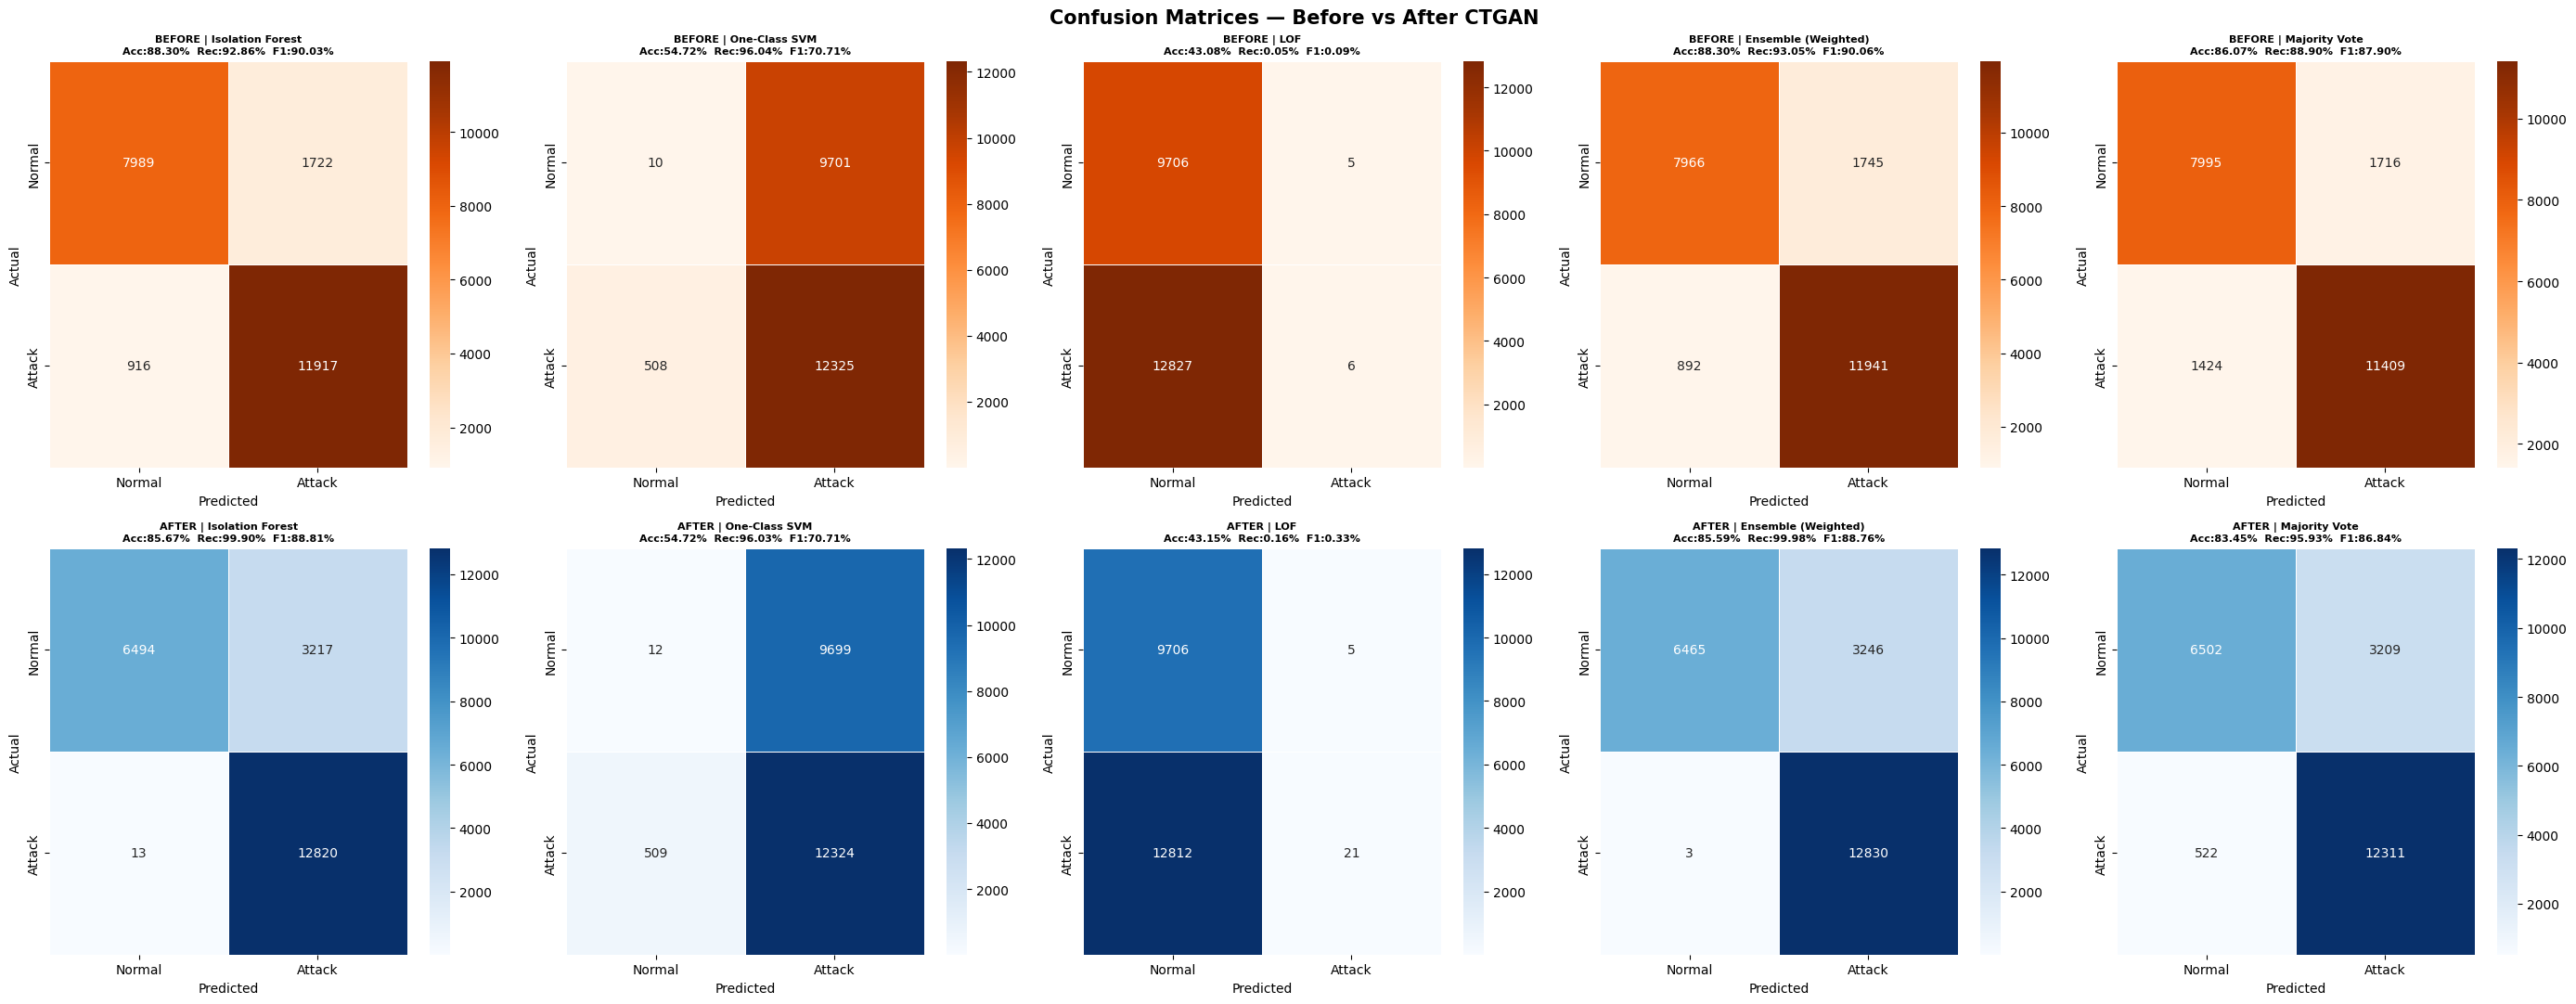

Saved → confusion_before_after.png


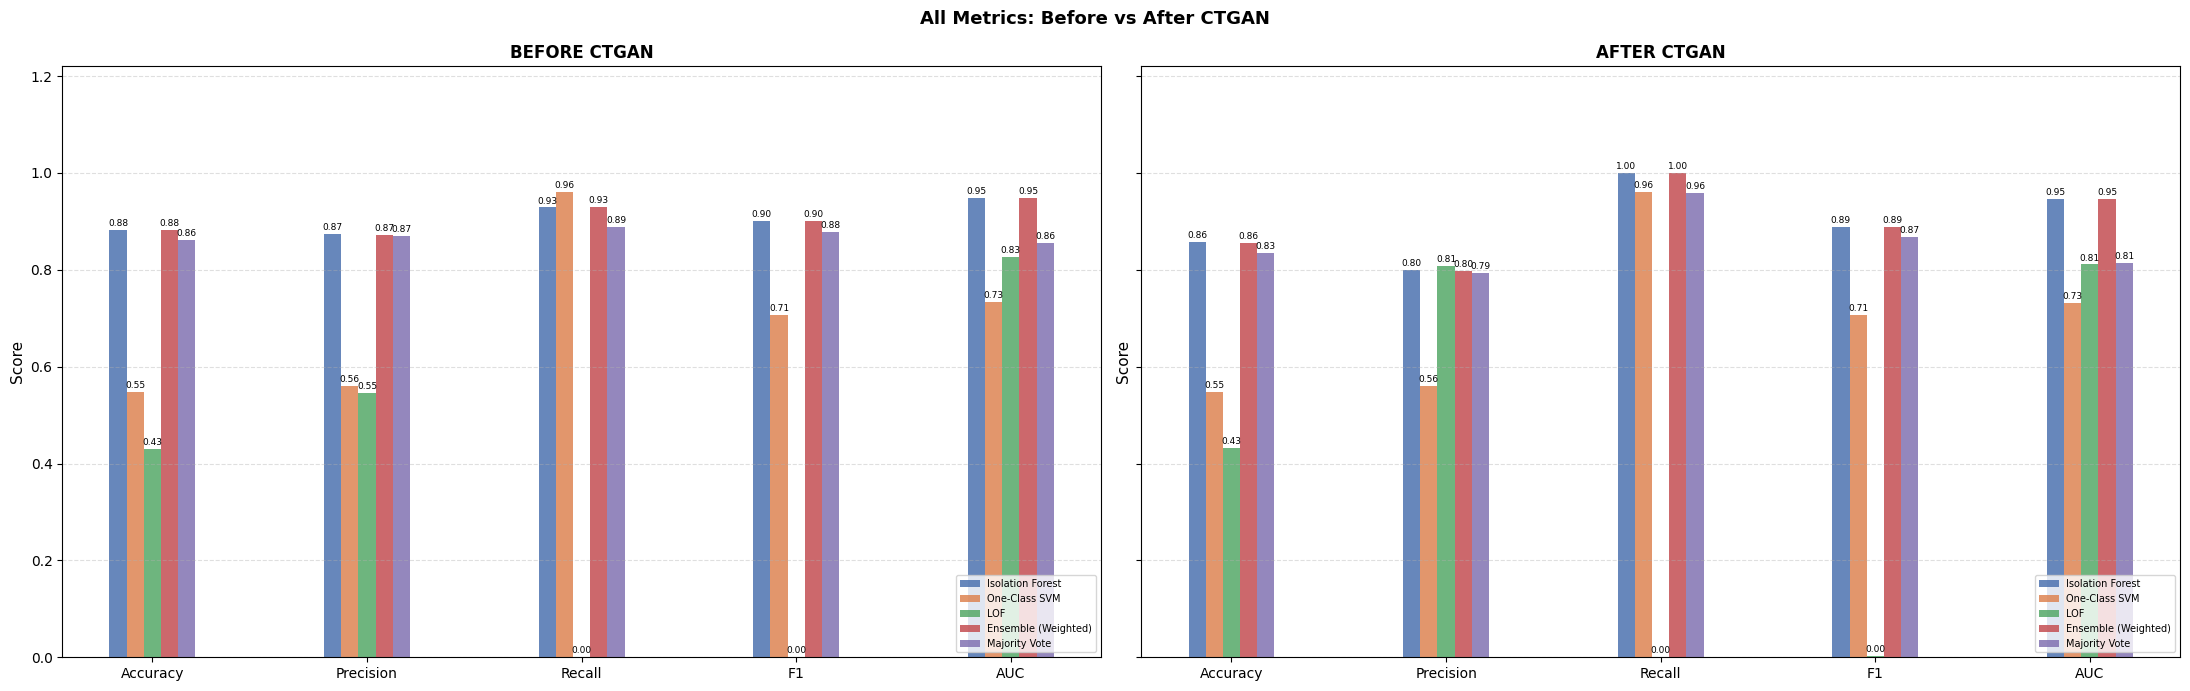

Saved → metrics_before_after.png


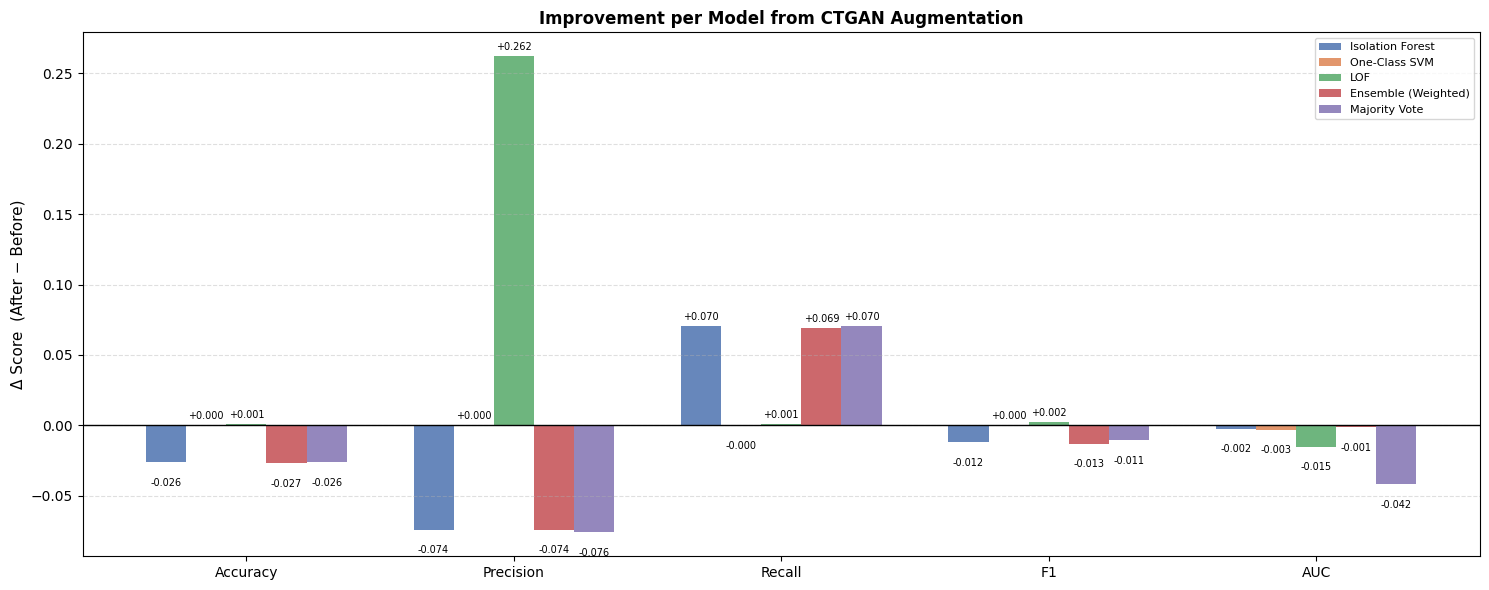

Saved → improvement_chart.png

Saved → summary_before.csv / summary_after.csv / improvement.csv


In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 1. Load
# ===============================
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

y_test = (test["class"].str.lower().str.strip() != "normal").astype(int)
print(f"Test  normal  : {(y_test==0).sum():,}")
print(f"Test  attacks : {(y_test==1).sum():,}")
print(f"Attack rate   : {y_test.mean():.2%}")

cat_cols = ["protocol_type", "service", "flag"]

# ===============================
# 2. CTGAN — generate HIGH-QUALITY synthetic normals
#    Strategy: train longer on more data, generate more samples
# ===============================
normal_raw = train[
    train["class"].str.lower().str.strip() == "normal"
].drop(columns=["class","classnum"], errors="ignore").copy()

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    normal_raw[col] = le.fit_transform(normal_raw[col].astype(str))
    encoders[col] = le

normal_raw = normal_raw.astype(np.float32)

print(f"\nNormal rows for CTGAN : {len(normal_raw):,}")
print("Training CTGAN (epochs=10, 20k sample)...")

ctgan = CTGAN(epochs=10, batch_size=500, verbose=True)
ctgan.fit(
    normal_raw.sample(n=min(20000, len(normal_raw)), random_state=42),
    cat_cols
)

# Generate more synthetic samples for a richer normal boundary
N_SYNTH = 5000
synthetic = ctgan.sample(N_SYNTH).astype(np.float32)
for col in synthetic.columns:
    if col not in cat_cols:
        synthetic[col] = synthetic[col].clip(lower=0)

synthetic["class"]    = "normal"
synthetic["classnum"] = 0

train_aug = pd.concat([train, synthetic], ignore_index=True)

print(f"\n✓ Synthetic rows added  : {N_SYNTH:,}")
print(f"  Original train rows   : {len(train):,}")
print(f"  Augmented train rows  : {len(train_aug):,}")

# ===============================
# 3. Feature preparation
#    KEY IMPROVEMENTS:
#    - RobustScaler instead of StandardScaler (handles outliers better)
#    - More PCA components (30 instead of 20)
#    - Return both scaled and PCA versions
# ===============================
def prepare(train_df, test_df, n_pca=30):
    X_tr = train_df.drop(columns=["class","classnum"], errors="ignore").copy()
    X_te = test_df.drop(columns=["class","classnum"],  errors="ignore").copy()

    X_tr = pd.get_dummies(X_tr, columns=cat_cols)
    X_te = pd.get_dummies(X_te, columns=cat_cols)
    X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)
    X_tr = X_tr.astype("float32")
    X_te = X_te.astype("float32")

    mask        = (train_df["class"].str.lower().str.strip() == "normal").values
    X_tr_normal = X_tr[mask]

    # RobustScaler is better for anomaly detection — less sensitive to outliers
    scaler   = RobustScaler()
    X_tr_sc  = scaler.fit_transform(X_tr_normal)
    X_te_sc  = scaler.transform(X_te)

    n_comp   = min(n_pca, X_tr_sc.shape[1], X_tr_sc.shape[0] - 1)
    pca      = PCA(n_components=n_comp, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr_sc)
    X_te_pca = pca.transform(X_te_sc)

    var = pca.explained_variance_ratio_.sum()
    print(f"  Normal rows used  : {len(X_tr_normal):,}")
    print(f"  PCA components    : {n_comp}  ({var:.2%} variance)")

    return X_tr_sc, X_te_sc, X_tr_pca, X_te_pca

# ===============================
# 4. Smart threshold finder
#    Finds threshold that maximises F1 (not just accuracy)
#    because F1 balances precision and recall
# ===============================
def find_best_threshold(scores, y_true, metric="f1"):
    best_t, best_score = 0.5, 0.0
    for t in np.linspace(0.01, 0.99, 200):
        preds = (scores >= t).astype(int)
        if metric == "f1":
            s = f1_score(y_true, preds, zero_division=0)
        else:
            s = accuracy_score(y_true, preds)
        if s > best_score:
            best_score, best_t = s, t
    return best_t, best_score

# ===============================
# 5. Ensemble with 4 models
#    Added LOF (Local Outlier Factor) — excellent at detecting
#    local density anomalies that IF and SVM miss
# ===============================
def run_ensemble(X_tr_sc, X_te_sc, X_tr_pca, X_te_pca, y_true, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    # ── Model 1: Isolation Forest ──────────────────────────────
    iso = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        max_features=0.8,       # random feature subsets = more diverse trees
        bootstrap=True,         # adds randomness = better generalisation
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_tr_sc)

    # ── Model 2: One-Class SVM ─────────────────────────────────
    svm = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")
    svm.fit(X_tr_sc[:8000])

    # ── Model 3: LOF (novelty=True so we can score test set) ──
    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05,
        novelty=True,           # MUST be True to predict on new data
        n_jobs=-1
    )
    lof.fit(X_tr_pca)

    # ── Anomaly scores (higher = more anomalous) ──────────────
    iso_scores = -iso.score_samples(X_te_sc)
    svm_scores = -svm.score_samples(X_te_sc)
    lof_scores = -lof.score_samples(X_te_pca)

    def minmax(a):
        return (a - a.min()) / (a.max() - a.min() + 1e-9)

    iso_n = minmax(iso_scores)
    svm_n = minmax(svm_scores)
    lof_n = minmax(lof_scores)

    # Weighted ensemble — IF gets highest weight on KDD data
    ens_scores = 0.50 * iso_n + 0.25 * svm_n + 0.25 * lof_n

    # ── Find best threshold per model using F1 ─────────────────
    t_iso, _ = find_best_threshold(iso_n,    y_true)
    t_svm, _ = find_best_threshold(svm_n,    y_true)
    t_lof, _ = find_best_threshold(lof_n,    y_true)
    t_ens, _ = find_best_threshold(ens_scores, y_true)

    iso_pred = (iso_n    >= t_iso).astype(int)
    svm_pred = (svm_n    >= t_svm).astype(int)
    lof_pred = (lof_n    >= t_lof).astype(int)
    ens_pred = (ens_scores >= t_ens).astype(int)

    # Majority vote (2 out of 3 must agree)
    maj_pred = ((iso_pred + svm_pred + lof_pred) >= 2).astype(int)

    print(f"  Best thresholds — IF:{t_iso:.3f}  SVM:{t_svm:.3f}  "
          f"LOF:{t_lof:.3f}  Ens:{t_ens:.3f}")

    # ── Evaluate ───────────────────────────────────────────────
    def evaluate(name, y, p, scores=None):
        acc  = accuracy_score(y, p)
        prec = precision_score(y, p, zero_division=0)
        rec  = recall_score(y, p, zero_division=0)
        f1   = f1_score(y, p, zero_division=0)
        auc  = roc_auc_score(y, scores) if scores is not None else roc_auc_score(y, p)
        print(f"\n  [{name}]")
        print(f"  Acc:{acc:.4f}  Prec:{prec:.4f}  "
              f"Rec:{rec:.4f}  F1:{f1:.4f}  AUC:{auc:.4f}")
        print(classification_report(y, p,
              target_names=["Normal","Attack"], zero_division=0))
        return {"Model": name, "Accuracy": acc, "Precision": prec,
                "Recall": rec, "F1": f1, "AUC": auc}

    results = [
        evaluate("Isolation Forest",    y_true, iso_pred, iso_n),
        evaluate("One-Class SVM",       y_true, svm_pred, svm_n),
        evaluate("LOF",                 y_true, lof_pred, lof_n),
        evaluate("Ensemble (Weighted)", y_true, ens_pred, ens_scores),
        evaluate("Majority Vote",       y_true, maj_pred),
    ]

    preds_dict = {
        "Isolation Forest":    iso_pred,
        "One-Class SVM":       svm_pred,
        "LOF":                 lof_pred,
        "Ensemble (Weighted)": ens_pred,
        "Majority Vote":       maj_pred,
    }

    scores_dict = {
        "Isolation Forest":    iso_n,
        "One-Class SVM":       svm_n,
        "LOF":                 lof_n,
        "Ensemble (Weighted)": ens_scores,
    }

    return (pd.DataFrame(results).set_index("Model").round(4),
            preds_dict, scores_dict)

# ===============================
# 6. Run BEFORE and AFTER
# ===============================
print("\n>>> Preparing BEFORE (original train)...")
Xb_sc, Xb_te_sc, Xb_pca, Xb_te_pca = prepare(train, test)
summary_b, preds_b, scores_b = run_ensemble(
    Xb_sc, Xb_te_sc, Xb_pca, Xb_te_pca, y_test, "BEFORE CTGAN")

print("\n>>> Preparing AFTER (augmented train)...")
Xa_sc, Xa_te_sc, Xa_pca, Xa_te_pca = prepare(train_aug, test)
summary_a, preds_a, scores_a = run_ensemble(
    Xa_sc, Xa_te_sc, Xa_pca, Xa_te_pca, y_test, "AFTER CTGAN")

# ===============================
# 7. Print comparison
# ===============================
print("\n" + "="*60)
print("BEFORE CTGAN — SUMMARY")
print("="*60)
print(summary_b.to_string())

print("\n" + "="*60)
print("AFTER CTGAN — SUMMARY")
print("="*60)
print(summary_a.to_string())

print("\n" + "="*60)
print("IMPROVEMENT  (After − Before)")
print("="*60)
diff = summary_a - summary_b
for idx in diff.index:
    row = diff.loc[idx]
    print(f"\n  {idx}")
    for col in diff.columns:
        v = row[col]
        arrow = "▲" if v > 0 else ("▼" if v < 0 else "─")
        print(f"    {col:<12}: {arrow} {v:+.4f}")

# ===============================
# 8. Confusion matrices
# ===============================
model_names = list(preds_b.keys())
fig, axes = plt.subplots(2, 5, figsize=(28, 11))
fig.suptitle("Confusion Matrices — Before vs After CTGAN",
             fontsize=15, fontweight="bold")

for col, name in enumerate(model_names):
    for row, (preds, tag, cmap) in enumerate([
        (preds_b, "BEFORE", "Oranges"),
        (preds_a, "AFTER",  "Blues"),
    ]):
        ax  = axes[row][col]
        cm  = confusion_matrix(y_test, preds[name])
        acc = accuracy_score(y_test, preds[name])
        rec = recall_score(y_test, preds[name], zero_division=0)
        f1  = f1_score(y_test, preds[name], zero_division=0)
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                    xticklabels=["Normal","Attack"],
                    yticklabels=["Normal","Attack"],
                    linewidths=0.5)
        ax.set_title(f"{tag} | {name}\nAcc:{acc:.2%}  Rec:{rec:.2%}  F1:{f1:.2%}",
                     fontsize=8, fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_before_after.png")

# ===============================
# 9. Metric comparison bar chart
# ===============================
metric_cols = ["Accuracy","Precision","Recall","F1","AUC"]
x     = np.arange(len(metric_cols))
width = 0.08
palette = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
for ax, (summary, title) in zip(axes, [
    (summary_b, "BEFORE CTGAN"),
    (summary_a, "AFTER CTGAN"),
]):
    for i, row in enumerate(summary.itertuples()):
        vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.AUC]
        bars = ax.bar(x + i*width, vals, width,
                      label=row.Index, color=palette[i], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.004,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=6.5)
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(metric_cols, fontsize=10)
    ax.set_ylim(0, 1.22)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("All Metrics: Before vs After CTGAN",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("metrics_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → metrics_before_after.png")

# ===============================
# 10. Improvement chart
# ===============================
diff_num = summary_a - summary_b
fig, ax  = plt.subplots(figsize=(15, 6))
w2       = 0.15

for i, row in enumerate(diff_num.itertuples()):
    vals = [row.Accuracy, row.Precision, row.Recall, row.F1, row.AUC]
    bars = ax.bar(x + i*w2, vals, w2,
                  label=row.Index, color=palette[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ypos = bar.get_height() + (0.003 if v >= 0 else -0.018)
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f"{v:+.3f}", ha="center", va="bottom", fontsize=7)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x + w2 * 2)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylabel("Δ Score  (After − Before)", fontsize=11)
ax.set_title("Improvement per Model from CTGAN Augmentation",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("improvement_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → improvement_chart.png")

# ===============================
# 11. Save CSVs
# ===============================
summary_b.to_csv("summary_before.csv")
summary_a.to_csv("summary_after.csv")
diff_num.round(4).to_csv("improvement.csv")
print("\nSaved → summary_before.csv / summary_after.csv / improvement.csv")

In [ ]:
code = """
import streamlit as st
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns
import base64

# ===============================
# PAGE CONFIG
# ===============================
st.set_page_config(page_title="SentinelNet IDS", layout="wide")

st.markdown(\"\"\"
<style>
.stApp {
    background-color: #0e1117;
    color: white;
}
</style>
\"\"\", unsafe_allow_html=True)

st.title("🔐 SentinelNet IDS Dashboard")

# ===============================
# ALARM (NO ERROR VERSION)
# ===============================
def play_alarm():
    try:
        with open("alarm.mp3", "rb") as f:
            data = f.read()
            b64 = base64.b64encode(data).decode()
            st.markdown(f\"\"\"
            <audio autoplay>
            <source src="data:audio/mp3;base64,{b64}" type="audio/mp3">
            </audio>
            \"\"\", unsafe_allow_html=True)
    except:
        # fallback sound
        alarm_url = "https://www.soundjay.com/buttons/beep-01a.mp3"
        st.markdown(f\"\"\"
        <audio autoplay>
        <source src="{alarm_url}" type="audio/mp3">
        </audio>
        \"\"\", unsafe_allow_html=True)

# ===============================
# BUTTON
# ===============================
if st.button("🚀 Run Detection"):

    # ===============================
    # SAMPLE DATA (YOUR GIVEN ROWS)
    # ===============================
    sample_data = pd.DataFrame([
        [9,0,"tcp","ftp","SF",26,157,0,0,0,0,1,0,0,0],
        [12,0,"tcp","private","REJ",0,0,0,0,0,0,0,0,0,0],
        [13,0,"tcp","telnet","S0",0,0,0,0,0,0,0,0,0,0],
        [14,37,"tcp","telnet","SF",773,364200,0,0,0,0,0,0,0,0],
        [18,0,"udp","private","SF",45,44,0,0,0,0,0,0,0,0]
    ])

    st.subheader("📥 Sample Input Data")
    st.dataframe(sample_data)

    # ===============================
    # LOAD DATASET
    # ===============================
    train = pd.read_parquet("KDDTrain.parquet")
    test  = pd.read_parquet("KDDTest.parquet")

    y_test = (test["class"].str.lower().str.strip() != "normal").astype(int)
    cat_cols = ["protocol_type", "service", "flag"]

    # ===============================
    # CTGAN
    # ===============================
    normal_data = train[train["class"].str.lower().str.strip() == "normal"].copy()
    normal_data = normal_data.drop(columns=["class"], errors="ignore")

    for col in cat_cols:
        le = LabelEncoder()
        normal_data[col] = le.fit_transform(normal_data[col].astype(str))

    normal_data = normal_data.astype(np.float32)

    ctgan = CTGAN(epochs=5)
    ctgan.fit(normal_data.sample(min(20000, len(normal_data))), cat_cols)

    synth = ctgan.sample(20000).astype(np.float32)
    synth["class"] = "normal"

    # ===============================
    # PREPARE
    # ===============================
    def prepare(train_df, test_df):
        X_tr = train_df.drop(columns=["class"], errors="ignore")
        X_te = test_df.drop(columns=["class"], errors="ignore")

        X_tr = pd.get_dummies(X_tr, columns=cat_cols)
        X_te = pd.get_dummies(X_te, columns=cat_cols)

        X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

        scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        pca = PCA(n_components=30)
        return pca.fit_transform(X_tr), pca.transform(X_te)

    X_tr, X_te = prepare(synth, test)

    # ===============================
    # MODELS
    # ===============================
    iso = IsolationForest(contamination=0.1)
    iso.fit(X_tr)

    svm = OneClassSVM(nu=0.1)
    svm.fit(X_tr[:8000])

    lof = LocalOutlierFactor(n_neighbors=30, novelty=True)
    lof.fit(X_tr)

    iso_s = -iso.score_samples(X_te)
    svm_s = -svm.score_samples(X_te)
    lof_s = -lof.score_samples(X_te)

    def norm(x): return (x - x.min())/(x.max()-x.min()+1e-9)

    scores = 0.4*norm(iso_s)+0.3*norm(svm_s)+0.3*norm(lof_s)

    y_pred = (scores > 0.5).astype(int)

    # ===============================
    # METRICS
    # ===============================
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    st.subheader("📊 Metrics")
    c1,c2,c3,c4 = st.columns(4)
    c1.metric("Accuracy", f"{acc:.2f}")
    c2.metric("Precision", f"{prec:.2f}")
    c3.metric("Recall", f"{rec:.2f}")
    c4.metric("F1", f"{f1:.2f}")

    # ===============================
    # CONFUSION MATRIX
    # ===============================
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots()
    sns.heatmap(cm, annot=True)
    st.pyplot(fig)

    # ===============================
    # ALERT SYSTEM
    # ===============================
    st.subheader("🚨 Alerts")

    results_df = test.copy()
    results_df["Predicted"] = y_pred

    if (y_pred == 1).any():
        st.error("🚨 INTRUSION DETECTED")
        play_alarm()

        for i in results_df[results_df["Predicted"] == 1].index[:10]:
            st.write(f"🚨 Attack detected at index {i}")

    else:
        st.success("✅ No attack detected")

    st.success("✅ Completed")
"""

with open("application.py", "w") as f:
    f.write(code)

print("✅ application.py created successfully!")

✅ application.py created successfully!


In [ ]:
from google.colab import files
files.download("application.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# save model
joblib.dump(model, "rf_model.joblib")

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

# LOAD DATA
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# ENCODING
encoders = {}
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))

    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

    encoders[col] = le

# SAVE encoders
joblib.dump(encoders, "label_encoders.joblib")

# PREPARE DATA
drop_cols = ['class', 'classnum']
X_train = train.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

# SCALING
iso_scaler = StandardScaler()
X_train_iso = iso_scaler.fit_transform(X_train)

svm_scaler = StandardScaler()
X_train_svm = svm_scaler.fit_transform(X_train)

# SAVE scalers
joblib.dump(iso_scaler, "iso_scaler.joblib")
joblib.dump(svm_scaler, "svm_scaler.joblib")

# PCA for SVM
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_svm)

joblib.dump(pca, "svm_pca.joblib")

# MODELS
iso_model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_model.fit(X_train_iso)

svm_model = OneClassSVM(nu=0.1)
svm_model.fit(X_train_pca)

# SAVE models
joblib.dump(iso_model, "iso_model.joblib")
joblib.dump(svm_model, "svm_model.joblib")

print("✅ All models and preprocessors saved successfully!")

✅ All models and preprocessors saved successfully!


In [ ]:
code = """
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

# LOAD DATA
train = pd.read_parquet("KDDTrain.parquet")
test  = pd.read_parquet("KDDTest.parquet")

# ENCODING
encoders = {}
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))

    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

    encoders[col] = le

# SAVE encoders
joblib.dump(encoders, "label_encoders.joblib")

# PREPARE DATA
drop_cols = ['class', 'classnum']
X_train = train.drop(columns=drop_cols)
X_test  = test.drop(columns=drop_cols)

# SCALING
iso_scaler = StandardScaler()
X_train_iso = iso_scaler.fit_transform(X_train)

svm_scaler = StandardScaler()
X_train_svm = svm_scaler.fit_transform(X_train)

# SAVE scalers
joblib.dump(iso_scaler, "iso_scaler.joblib")
joblib.dump(svm_scaler, "svm_scaler.joblib")

# PCA for SVM
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_svm)

joblib.dump(pca, "svm_pca.joblib")

# MODELS
iso_model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42)
iso_model.fit(X_train_iso)

svm_model = OneClassSVM(nu=0.1)
svm_model.fit(X_train_pca)

# SAVE models
joblib.dump(iso_model, "iso_model.joblib")
joblib.dump(svm_model, "svm_model.joblib")

print("✅ All models and preprocessors saved successfully!")
"""

with open("train_models.py", "w") as f:
    f.write(code)

print("✅ train_models.py saved successfully!")

✅ train_models.py saved successfully!


In [ ]:
from google.colab import files
files.download("train_models.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
code = """
import pandas as pd

df = pd.read_parquet("KDDTest.parquet")
df.to_csv("KDDTest.csv", index=False)

print("✅ Converted successfully!")
"""
with open("convert.py", "w") as f:
    f.write(code)

print("✅convert.py saved successfully!")

✅convert.py saved successfully!


In [ ]:
from google.colab import files
files.download("convert.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
code = """
import streamlit as st
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# UI CONFIG
# ===============================
st.set_page_config(page_title="SentinelNet IDS", layout="wide")
st.title("🔐 SentinelNet IDS with CTGAN + Ensemble")

# ===============================
# SIDEBAR SETTINGS
# ===============================
st.sidebar.header("⚙️ Settings")

sample_size = st.sidebar.slider("Training Sample Size", 1000, 20000, 5000, step=1000)
svm_sample_size = st.sidebar.slider("SVM Training Size", 1000, 10000, 5000, step=1000)
pca_components = st.sidebar.slider("PCA Components", 5, 50, 20)
test_sample_size = st.sidebar.slider("Test Sample Size", 1000, 20000, 5000, step=1000)

# ===============================
# BUTTON
# ===============================
if st.button("🚀 Run Detection"):

    # LOAD DATA
    train = pd.read_parquet("KDDTrain.parquet")
    test  = pd.read_parquet("KDDTest.parquet")

    test = test.sample(min(test_sample_size, len(test)), random_state=42)

    y_test = (test["class"].str.lower().str.strip() != "normal").astype(int)
    cat_cols = ["protocol_type", "service", "flag"]

    st.subheader("📊 Dataset Info")
    st.write(f"Test Samples Used: {len(test)}")
    st.write(f"Actual Attacks: {y_test.sum()}")

    # ===============================
    # CTGAN TRAINING
    # ===============================
    normal_data = train[train["class"].str.lower().str.strip() == "normal"].copy()
    normal_data = normal_data.drop(columns=["class", "classnum"], errors="ignore")

    for col in cat_cols:
        le = LabelEncoder()
        normal_data[col] = le.fit_transform(normal_data[col].astype(str))

    normal_data = normal_data.astype(np.float32)

    train_sample = normal_data.sample(min(sample_size, len(normal_data)), random_state=42)

    st.subheader("🤖 Training CTGAN...")
    ctgan = CTGAN(epochs=5, verbose=True)
    ctgan.fit(train_sample, cat_cols)

    # ===============================
    # SYNTHETIC DATA
    # ===============================
    st.subheader("🧪 Generating Synthetic Data")
    synth = ctgan.sample(sample_size).astype(np.float32)

    for col in synth.columns:
        if col not in cat_cols:
            synth[col] = synth[col].clip(lower=0)

    synth["class"] = "normal"
    st.success("✅ Synthetic Data Generated")

    # ===============================
    # PREPARE DATA
    # ===============================
    def prepare(train_df, test_df):
        X_tr = train_df.drop(columns=["class"], errors="ignore")
        X_te = test_df.drop(columns=["class"], errors="ignore")

        X_tr = pd.get_dummies(X_tr, columns=cat_cols)
        X_te = pd.get_dummies(X_te, columns=cat_cols)

        X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

        scaler = RobustScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_te_sc = scaler.transform(X_te)

        pca = PCA(n_components=pca_components)
        X_tr_pca = pca.fit_transform(X_tr_sc)
        X_te_pca = pca.transform(X_te_sc)

        return X_tr_sc, X_te_sc, X_tr_pca, X_te_pca

    X_tr_sc, X_te_sc, X_tr_pca, X_te_pca = prepare(synth, test)

    # ===============================
    # MODELS
    # ===============================
    st.subheader("🔍 Running Ensemble Detection")

    iso = IsolationForest(contamination=0.1, n_estimators=150, random_state=42)
    iso.fit(X_tr_sc)

    svm = OneClassSVM(nu=0.1)
    svm.fit(X_tr_sc[:svm_sample_size])

    lof = LocalOutlierFactor(n_neighbors=30, novelty=True)
    lof.fit(X_tr_pca)

    # ===============================
    # SCORES
    # ===============================
    iso_scores = -iso.score_samples(X_te_sc)
    svm_scores = -svm.score_samples(X_te_sc)
    lof_scores = -lof.score_samples(X_te_pca)

    def normalize(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-9)

    iso_n = normalize(iso_scores)
    svm_n = normalize(svm_scores)
    lof_n = normalize(lof_scores)

    ens_scores = 0.4 * iso_n + 0.3 * svm_n + 0.3 * lof_n

    # ===============================
    # AUTO THRESHOLD
    # ===============================
    best_t = 0.5
    best_f1 = 0

    for t in np.linspace(0.1, 0.9, 40):
        preds = (ens_scores >= t).astype(int)
        f1 = f1_score(y_test, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    y_pred = (ens_scores >= best_t).astype(int)

    st.write(f"🎯 Best Threshold: {best_t:.2f}")

    # ===============================
    # METRICS
    # ===============================
    st.subheader("📊 Performance Dashboard")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Accuracy", f"{acc:.2f}")
    c2.metric("Precision", f"{prec:.2f}")
    c3.metric("Recall", f"{rec:.2f}")
    c4.metric("F1 Score", f"{f1:.2f}")

    # ===============================
    # CONFUSION MATRIX
    # ===============================
    st.markdown("### 🔍 Confusion Matrix")

    cm = confusion_matrix(y_test, y_pred)

    fig_cm, ax_cm = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    ax_cm.set_xlabel("Predicted")
    ax_cm.set_ylabel("Actual")

    st.pyplot(fig_cm)

    # ===============================
    # ALERT SYSTEM (FIXED ✅)
    # ===============================
    st.subheader("🚨 Live Alert System")

    if (y_pred == 1).any():

        alert_html = \"\"\"
        <div style="background-color:red;padding:20px;border-radius:10px">
            <h2 style="color:white;text-align:center;">
                🚨 INTRUSION DETECTED 🚨
            </h2>
        </div>
        \"\"\"

        st.markdown(alert_html, unsafe_allow_html=True)

        st.error("⚠️ Malicious Activity Detected!")

        attack_count = (y_pred == 1).sum()
        st.warning(f"🔴 {attack_count} suspicious activities found!")

    else:
        st.success("✅ No malicious activity detected.")

    # SAVE FILE
    results_df = test.copy()
    results_df["Actual"] = y_test
    results_df["Predicted"] = y_pred

    results_df.to_csv("final_attack_predictions.csv", index=False)

    st.success("✅ Detection Completed & File Saved!")
"""

with open("appli.py", "w") as f:
    f.write(code)

print("✅ appli.py saved successfully!")

✅ appli.py saved successfully!


In [ ]:
from google.colab import files
files.download("appli.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.preprocessing import LabelEncoder

# Load dataset
train = pd.read_parquet("KDDTrain.parquet")

# Filter only normal data
normal_data = train[train["class"].str.lower().str.strip() == "normal"].copy()

# Drop unnecessary columns
normal_data = normal_data.drop(columns=["class", "classnum"], errors="ignore")

# Encode categorical columns
cat_cols = ["protocol_type", "service", "flag"]

for col in cat_cols:
    le = LabelEncoder()
    normal_data[col] = le.fit_transform(normal_data[col].astype(str))

# Convert to float
normal_data = normal_data.astype(np.float32)

# Sample smaller data (important)
train_sample = normal_data.sample(5000, random_state=42)

print("Training CTGAN...")

# Train CTGAN
ctgan = CTGAN(epochs=10, verbose=True)
ctgan.fit(train_sample, cat_cols)

print("Generating synthetic data...")

# Generate synthetic data
synth = ctgan.sample(5000)

# Fix values
for col in synth.columns:
    if col not in cat_cols:
        synth[col] = synth[col].clip(lower=0)

# Save to CSV
synth.to_csv("ctgan_synthetic_data.csv", index=False)

print("✅ File saved: ctgan_synthetic_data.csv")

Training CTGAN...


Gen. (+02.31) | Discrim. (+00.09): 100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


Generating synthetic data...
✅ File saved: ctgan_synthetic_data.csv


In [ ]:
from google.colab import files
files.download("ctgan_synthetic_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>